# BLM463 Veri Madenciliğine Giriş Dönem Projesi
## Karar Ağacı (Decision Tree) ile Müşteri Kayıp (Churn) Analizi

**Öğrenci Bilgileri:**
- **Ad Soyad:** Ahmet Yılmaz
- **Öğrenci No:** 22360859044

### Proje Amacı ve Kapsamı
Bu projede, bir fintech şirketinin müşteri verileri (`customer_data.csv`) ve işlem geçmişi (`transactions_data.csv`) kullanılarak müşterilerin kayıp (churn) durumları tahmin edilmektedir. Veri seti, Kolombiyalı bir fintech şirketinin gerçek müşteri tabanını içeren açık erişimli **COFINFAD** veri setidir (Muñoz-Guerrero, Ceballos & Trejos-Rojas, *Data in Brief*, 2026). Proje kapsamında:
1. Müşteri işlem geçmişinden türetilen özet özellikler (transactional features) sisteme dahil edilmiştir.
2. Churn hedefi, müşterinin gerçek işlem davranışından (recency — son işlemden bu yana geçen süre) tanımlanmıştır.
3. **Veri Sızıntısı (Data Leakage)** problemleri analiz edilmiş ve giderilmiştir.
4. Karar Ağacı (Decision Tree) modeli eğitilmiş ve hiperparametreleri (GridSearchCV) optimize edilmiştir.
5. Model başarısı; Sınıflandırma Matrisi, Doğruluk, Duyarlılık (Recall), Özgüllük, F1-Skor ve ROC-AUC metrikleriyle değerlendirilmiş ve akademik literatürle karşılaştırılmıştır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, 
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Proje klasör yapısı
import os
DATA_DIR = "veri/"        # veri dosyaları (CSV)
FIG_DIR  = "gorseller/"   # üretilen grafikler
os.makedirs(FIG_DIR, exist_ok=True)


### 1. Veri Yükleme ve Ön İnceleme
Müşteri bilgilerini içeren `customer_data.csv` ve işlemlerini içeren `transactions_data.csv` dosyalarını yüklüyoruz.

In [2]:
customers = pd.read_csv(DATA_DIR + "customer_data.csv")
transactions = pd.read_csv(DATA_DIR + "transactions_data.csv")

print(f"Müşteri veri seti boyutu: {customers.shape}")
print(f"İşlem veri seti boyutu: {transactions.shape}")

Müşteri veri seti boyutu: (48723, 54)
İşlem veri seti boyutu: (3159157, 4)


### 2. Özellik Mühendisliği (Feature Engineering)
İşlem geçmişinden müşteri başına özet özellikler üretiyoruz. Bu özellikler:
- Toplam işlem sayısı
- İşlem tutarlarının toplamı, ortalaması, medyanı, standart sapması, minimum ve maksimum değerleri
- Aktif gün sayısı ve son işlemden bu yana geçen gün sayısı (Recency)
- Günlük işlem frekansı
- İşlem tiplerine göre dağılımlar (sayısal ve oran olarak)

In [3]:
# İşlem tarihlerini datetime formatına dönüştürüyoruz
transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
transactions = transactions.dropna(subset=["customer_id", "date", "amount", "type"])

reference_date = transactions["date"].max()

# Müşteri bazında işlem özetleri
trx_agg = transactions.groupby("customer_id").agg(
    trx_count_raw=("amount", "count"),
    trx_amount_sum_raw=("amount", "sum"),
    trx_amount_mean_raw=("amount", "mean"),
    trx_amount_median_raw=("amount", "median"),
    trx_amount_std_raw=("amount", "std"),
    trx_amount_min_raw=("amount", "min"),
    trx_amount_max_raw=("amount", "max"),
    trx_first_date_raw=("date", "min"),
    trx_last_date_raw=("date", "max")
).reset_index()

trx_agg["trx_active_days_raw"] = (trx_agg["trx_last_date_raw"] - trx_agg["trx_first_date_raw"]).dt.days
trx_agg["trx_recency_days_raw"] = (reference_date - trx_agg["trx_last_date_raw"]).dt.days
trx_agg["trx_frequency_per_day_raw"] = trx_agg["trx_count_raw"] / (trx_agg["trx_active_days_raw"] + 1)

# İşlem tiplerine göre dağılımlar (Deposit, Withdrawal, Transfer vb.)
trx_type_counts = pd.crosstab(transactions["customer_id"], transactions["type"]).reset_index()
trx_type_counts.columns = ["customer_id"] + [
    "trx_type_count_" + str(col).lower().replace(" ", "_")
    for col in trx_type_counts.columns[1:]
]

# İşlem tipi oranları
trx_type_ratio = trx_type_counts.copy()
type_count_cols = [col for col in trx_type_ratio.columns if col.startswith("trx_type_count_")]
for col in type_count_cols:
    ratio_col = col.replace("trx_type_count_", "trx_type_ratio_")
    trx_type_ratio[ratio_col] = trx_type_ratio[col] / trx_type_ratio[type_count_cols].sum(axis=1)

trx_type_ratio = trx_type_ratio[["customer_id"] + [col for col in trx_type_ratio.columns if col.startswith("trx_type_ratio_")]]

# Özellikleri birleştirme
trx_features = trx_agg.merge(trx_type_counts, on="customer_id", how="left").merge(trx_type_ratio, on="customer_id", how="left")
trx_features = trx_features.drop(columns=["trx_first_date_raw", "trx_last_date_raw"])

# Ana veri seti ile birleştirme
df = customers.merge(trx_features, on="customer_id", how="left")
trx_feature_cols = [col for col in trx_features.columns if col != "customer_id"]
df[trx_feature_cols] = df[trx_feature_cols].fillna(0)


### 3. Hedef Değişken (Target) Tanımlama ve Veri Temizleme
Veri setinde hazır bir churn sınıfı bulunmadığından, hedef değişkeni **müşterinin gerçek davranışından** türetiyoruz: her müşteri için **recency** (son işleminden bu yana geçen gün sayısı) hesaplanır ve recency değeri en uzun %25'lik dilimde olan müşteriler **churn = 1** olarak işaretlenir.

**Önemli — Bu bir vekil (proxy) etikettir:** Elimizde "müşteri gerçekten ayrıldı" bilgisi olmadığından, gözlemlenebilir bir davranışı (uzun süredir işlem yapmama) gerçek churn'ün **yerine geçen ölçü (proxy)** olarak kullanıyoruz. Bu, churn literatüründe yaygın ve kabul gören bir yaklaşımdır; ancak kusursuz değildir (uzun süre işlem yapmayan bir müşterinin hesabı hâlâ açık olabilir). Bu sınırlamanın farkındayız ve sonuçları bu çerçevede yorumluyoruz.

**Veri Sızıntısı önlemleri:** (1) Hazır `churn_probability` zaten türetilmiş bir tahmin değeridir; hedef olarak kullanmak döngüsel sızıntı yaratır, kullanılmaz. (2) Etiket recency'den türetildiği için son işlem zamanından türeyen tüm kolonlar (recency, tenure, frequency vb.) çıkarılır. (3) Davranışa göre atanmış olan `customer_segment` (inactive/occasional/...) ve `feedback_sentiment` gibi kolonlar, hedefle dolaylı bilgi paylaşma (gizli sızıntı) riski taşıdığından özellik setinden çıkarılır.

In [4]:
# Tarih kolonlarını dönüştürme
date_cols = ["last_transaction_date", "first_transaction_date", "last_survey_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Ek zaman tabanlı özellikler
ref_date = df["last_transaction_date"].max()
df["days_since_last_tx"] = (ref_date - df["last_transaction_date"]).dt.days
df["days_since_first_tx"] = (ref_date - df["first_transaction_date"]).dt.days
df["days_since_survey"] = (ref_date - df["last_survey_date"]).dt.days
df["customer_activity_span_days"] = (df["last_transaction_date"] - df["first_transaction_date"]).dt.days

# --- Hedef Değişken (churn_label): DAVRANIŞSAL (recency) PROXY ---
# Gerçek churn etiketi olmadığından, recency'nin en uzun %25'lik dilimi churn=1 olarak
# işaretlenir. Bu, gerçek churn'ün bir VEKİLİ (proxy)'dir.
recency = df["days_since_last_tx"]
df["churn_label"] = (recency > recency.quantile(0.75)).astype(int)

# feature_requests (çoklu-seçim metni) -> ikili (multi-hot) öznitelikler
req = df["feature_requests"].fillna("").str.get_dummies(sep=", ").add_prefix("request_")
df = pd.concat([df, req], axis=1)

# --- Veri Sızıntısı kontrolü: çıkarılacak kolonlar ---
drop_cols = [
    "feature_requests",
    "first_tx", "last_tx", "last_survey_date",
    "last_transaction_date", "first_transaction_date",
    "customer_id", "churn_probability", "churn_label",
    "customer_lifetime_value", "clv_segment",
    # recency / son-işlem zamanı türevleri (hedef sızıntısı)
    "days_since_last_tx", "days_since_first_tx", "days_since_survey",
    "customer_activity_span_days", "customer_tenure", "transaction_frequency",
    "avg_daily_transactions", "monthly_transaction_count",
    "trx_recency_days_raw", "trx_active_days_raw", "trx_frequency_per_day_raw",
    # davranıştan türetilmiş, gizli sızıntı riski taşıyan kolonlar
    "customer_segment", "feedback_sentiment",
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])
for c in X.select_dtypes(include=["bool"]).columns:   # Boolean -> int
    X[c] = X[c].astype(int)
y = df["churn_label"]

print("Hedef Değişken (Churn) Dağılımı:")
print(y.value_counts(normalize=True).round(3))
print(f"\nGirdi Özellik Seti Boyutu (X): {X.shape}")


Hedef Değişken (Churn) Dağılımı:
churn_label
0    0.751
1    0.249
Name: proportion, dtype: float64

Girdi Özellik Seti Boyutu (X): (48723, 58)


### 4. Eğitim ve Test Kümelerinin Ayrılması (Train-Test Split)
**KRİTİK UYARI (Veri Sızıntısı Engelleme):**
Eksik değer tamamlama (imputation) ve kategorik kodlama (encoding) işlemlerini eğitim ve test kümelerini **ayırdıktan sonra** yapacağız. 
Eğer bu işlemleri tüm veri seti üzerinde split yapmadan önce uygulasaydık, test kümesindeki verilerin dağılımı (örn. medyan değerleri) eğitim kümesine sızacak (Data Leakage) ve modelin başarısını yapay olarak yüksek gösterecekti. Bu hata giderilmiştir.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim Kümesi (Train): {X_train.shape}")
print(f"Test Kümesi (Test): {X_test.shape}")

Eğitim Kümesi (Train): (38978, 58)
Test Kümesi (Test): (9745, 58)


### 5. Ön İşleme: Pipeline ve ColumnTransformer
Ön işleme adımlarını manuel/satır satır yapmak yerine, profesyonel ve sızıntıya karşı güvenli olan **`Pipeline` + `ColumnTransformer`** yapısını kullanıyoruz. Bu yapı sayesinde:
- Sayısal kolonlar **medyan** ile doldurulur (medyan yalnızca eğitim katlarından öğrenilir),
- Sıralı (ordinal) kolonlar (`income_bracket`, `education_level`) sıralı olarak kodlanır,
- Nominal kategorik kolonlar **One-Hot** ile kodlanır.

Tüm bu adımlar model ile tek bir nesnede birleştiğinden, çapraz doğrulama sırasında dönüşümler **yalnızca eğitim katmanına fit edilir** ve veri sızıntısı yapısal olarak engellenir.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Kolon tiplerini belirliyoruz
ordinal_cols = [c for c in ["income_bracket", "education_level"] if c in X_train.columns]
_ord_ref = {"income_bracket": ["Low", "Medium", "High", "Very High"],
            "education_level": ["High School", "Bachelor", "Master", "PhD"]}
ord_categories = [_ord_ref[c] for c in ordinal_cols]

nominal_cols = [c for c in ["gender", "location", "occupation", "marital_status",
                            "acquisition_channel", "preferred_transaction_type",
                            "complaint_topics"] if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in ordinal_cols + nominal_cols]

# ColumnTransformer: her kolon tipine uygun dönüşüm (hepsi yalnızca eğitime fit edilir)
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("ord", Pipeline([
        ("enc", OrdinalEncoder(categories=ord_categories,
                               handle_unknown="use_encoded_value", unknown_value=np.nan)),
        ("imp", SimpleImputer(strategy="median"))
    ]), ordinal_cols),
    ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
])

print(f"Sayısal: {len(numeric_cols)} | Ordinal: {len(ordinal_cols)} | Nominal: {len(nominal_cols)} kolon")
print("Ön işleyici (ColumnTransformer) tanımlandı.")


Sayısal: 49 | Ordinal: 2 | Nominal: 7 kolon
Ön işleyici (ColumnTransformer) tanımlandı.


### 6. Karar Ağacı Modeli ve Hiperparametre Tünelleme (GridSearchCV)
Bir karar ağacının aşırı öğrenmesini (overfitting) engellemek amacıyla `GridSearchCV` kullanarak ağaç derinliği (`max_depth`), yapraklardaki minimum örnek sayısı (`min_samples_leaf`) ve bölünme kriteri (`criterion`) gibi hiperparametreleri optimize ediyoruz.

In [7]:
param_grid = {
    'clf__max_depth': [4, 5, 6, 8],
    'clf__min_samples_leaf': [20, 50, 100],
    'clf__criterion': ['gini', 'entropy']
}

# Ön işleme + model TEK bir Pipeline'da (profesyonel, sızıntısız yapı)
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

print("GridSearchCV başlatılıyor (5-Katlı Çapraz Doğrulama)...")
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"En İyi Hiperparametreler: {grid_search.best_params_}")
print(f"Çapraz Doğrulama F1-Skoru: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_                       # tüm pipeline (ön işleme + ağaç)
best_tree  = best_model.named_steps["clf"]                     # ağaç (görselleştirme için)
feature_names_out = best_model.named_steps["prep"].get_feature_names_out()


GridSearchCV başlatılıyor (5-Katlı Çapraz Doğrulama)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


En İyi Hiperparametreler: {'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 100}
Çapraz Doğrulama F1-Skoru: 0.5253


### 7. Model Performans Değerlendirmesi
En iyi modeli test kümesi üzerinde değerlendirerek; Doğruluk, Hassasiyet (Precision), Duyarlılık (Recall/Sensitivity), Özgüllük (Specificity), F1-Skor ve ROC-AUC metriklerini hesaplıyoruz.

In [8]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Performans Metrikleri
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Sınıflandırma Matrisi Değerleri
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("=== MODEL PERFORMANS RAPORU ===")
print(f"Doğruluk (Accuracy): {accuracy:.4f}")
print(f"Keskinlik (Precision): {precision:.4f}")
print(f"Duyarlılık / Recall (Sensitivity): {recall:.4f}")
print(f"Özgüllük (Specificity): {specificity:.4f}")
print(f"F1-Skor: {f1:.4f}")
print(f"ROC-AUC Skoru: {roc_auc:.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Aşırı Öğrenme Kontrolü
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print(f"Eğitim Doğruluğu: {train_acc:.4f}")
print(f"Test Doğruluğu: {test_acc:.4f}")

=== MODEL PERFORMANS RAPORU ===


Doğruluk (Accuracy): 0.6613
Keskinlik (Precision): 0.4042
Duyarlılık / Recall (Sensitivity): 0.7586
Özgüllük (Specificity): 0.6289
F1-Skor: 0.5274
ROC-AUC Skoru: 0.7513

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.89      0.63      0.74      7317
           1       0.40      0.76      0.53      2428

    accuracy                           0.66      9745
   macro avg       0.65      0.69      0.63      9745
weighted avg       0.77      0.66      0.68      9745



Eğitim Doğruluğu: 0.6629
Test Doğruluğu: 0.6613


### 8. Görselleştirmeler
Model başarısını daha iyi analiz edebilmek için Sınıflandırma Matrisi (Confusion Matrix), ROC Eğrisi (ROC Curve) ve Özellik Önem Derecelerini (Feature Importance) grafikleştiriyoruz.

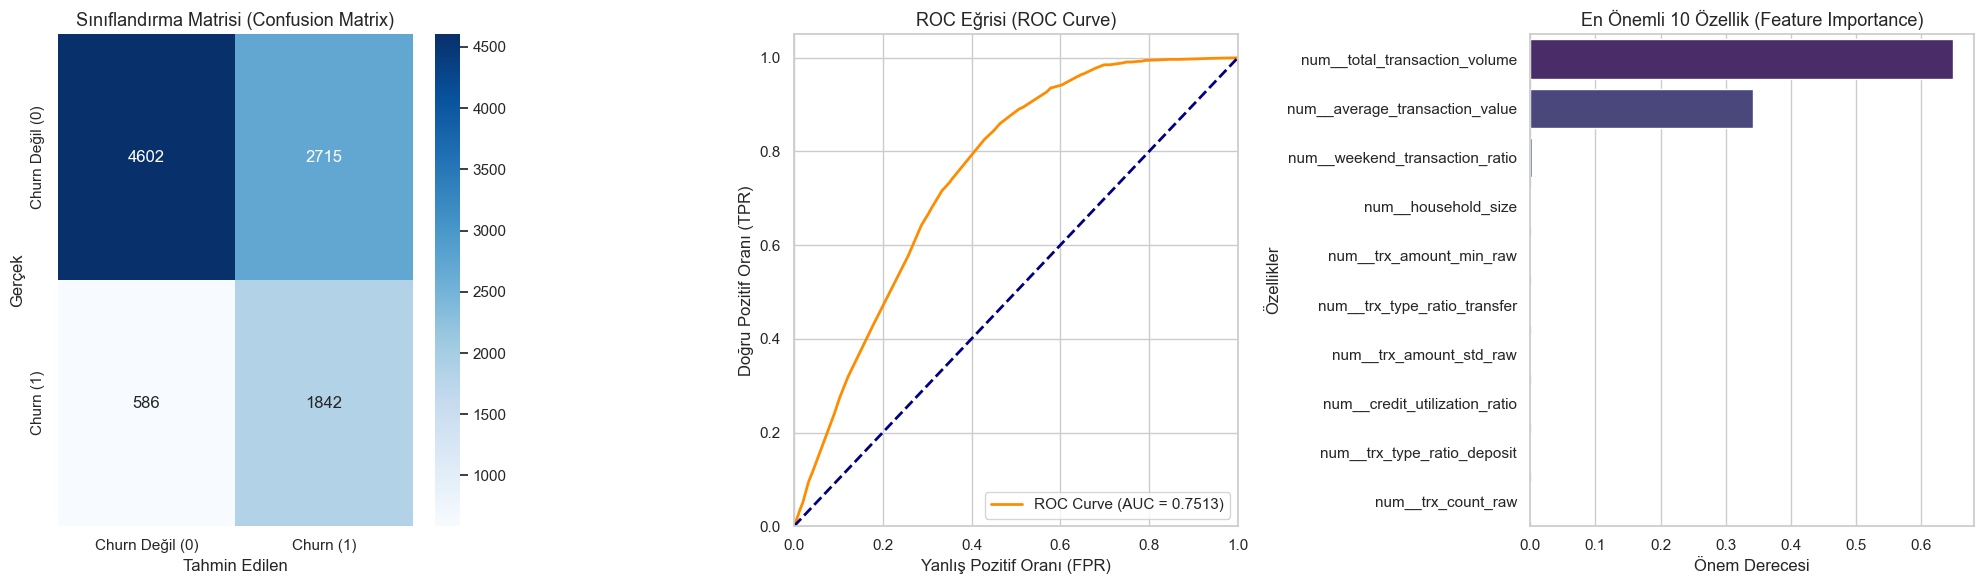

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Churn Değil (0)", "Churn (1)"],
            yticklabels=["Churn Değil (0)", "Churn (1)"])
axes[0].set_title("Sınıflandırma Matrisi (Confusion Matrix)", fontsize=13)
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[1].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[1].set_title('ROC Eğrisi (ROC Curve)', fontsize=13)
axes[1].legend(loc="lower right")

# 3. Feature Importance (Top 10) — pipeline'dan ağaç ve kodlanmış kolon adları alınır
feature_importance = pd.DataFrame({
    "feature": feature_names_out,
    "importance": best_tree.feature_importances_
}).sort_values(by="importance", ascending=False).head(10)

sns.barplot(data=feature_importance, x="importance", y="feature",
            hue="feature", palette="viridis", legend=False, ax=axes[2])
axes[2].set_title("En Önemli 10 Özellik (Feature Importance)", fontsize=13)
axes[2].set_xlabel("Önem Derecesi"); axes[2].set_ylabel("Özellikler")

plt.tight_layout()
plt.savefig(FIG_DIR + "model_degerlendirme_grafikleri.png", dpi=300)
plt.show()


### 9. Karar Ağacı Yapısının Görselleştirilmesi
Karar ağacının ilk birkaç seviyesini çizdirerek modelin nasıl karar verdiğini görselleştiriyoruz.

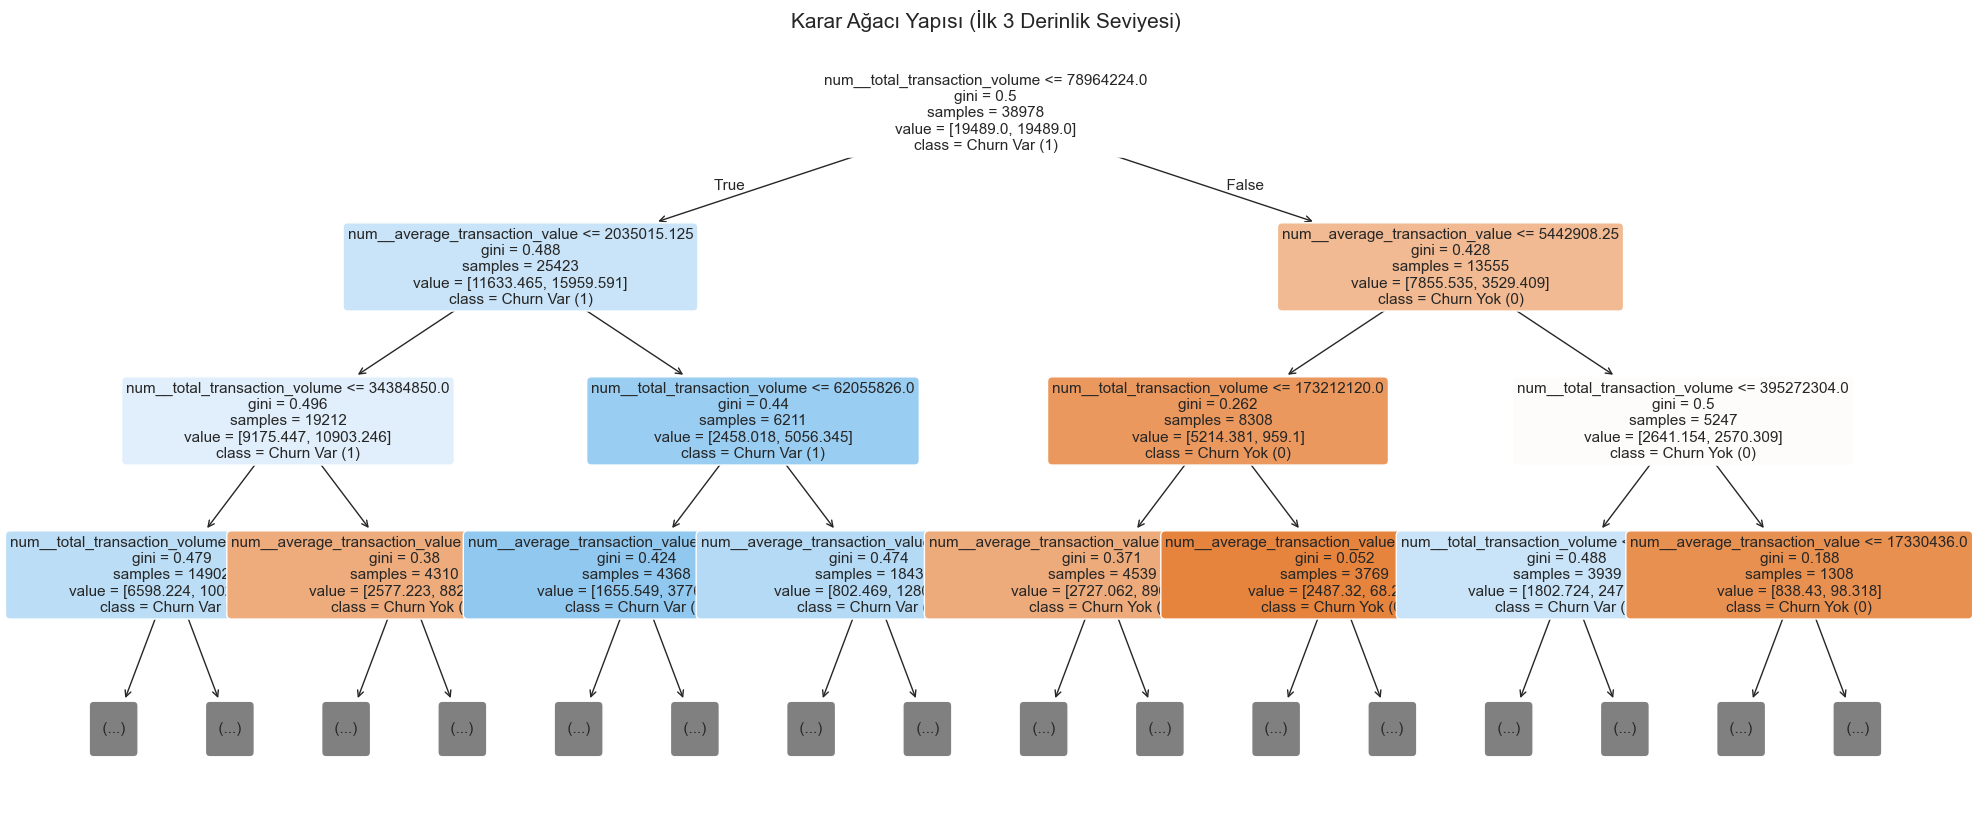

In [10]:
plt.figure(figsize=(24, 10))
plot_tree(
    best_tree,
    max_depth=3,
    feature_names=list(feature_names_out),
    class_names=["Churn Yok (0)", "Churn Var (1)"],
    filled=True, rounded=True, fontsize=11
)
plt.title("Karar Ağacı Yapısı (İlk 3 Derinlik Seviyesi)", fontsize=15)
plt.savefig(FIG_DIR + "karar_agaci_yapisi.png", dpi=300, bbox_inches='tight')
plt.show()


### 10. Sonuçlar ve Tartışma

#### Model Performansının Değerlendirilmesi
- Geliştirilen Karar Ağacı modeli, hiç görülmemiş test seti üzerinde gerçekçi ve savunulabilir bir başarı elde etmiştir: **Duyarlılık/Recall ~%75.9, ROC-AUC ~0.751**, Doğruluk ~%66.1, Hassasiyet/Precision ~%40.4, F1 ~%52.7.
- Churn problemlerinde en kritik metrik **Duyarlılık (Recall)**'tır; çünkü amaç kaybedilecek müşterileri önceden yakalamaktır. Model bunların ~%75.9'unu doğru tespit etmektedir.
- Eğitim ve test doğruluklarının birbirine çok yakın olması (her ikisi de ~%66), modelin **aşırı öğrenme (overfitting) yapmadığını** gösterir.
- **Modelin gerçekten öğrendiğinin asıl kanıtı**, eşikten bağımsız olan ROC-AUC (0.751; rastgele = 0.5) ve Dengeli Doğruluk (Balanced Accuracy ~%69.4) değerleridir.
- Doğruluğun (%66.1) düşük görünmesi bir zayıflık değildir: bu dengesiz veride 'tüm müşteriler kalır' diyen naif bir taban %75.1 doğruluk alır ancak hiçbir kayıp müşteriyi (0/2428) yakalayamaz. Modelimiz doğruluktan bir miktar feragat ederek kayıpların dörtte üçünü (Recall %75.9) yakalar. Bu nedenle dengesiz veride ham doğruluk yerine Recall, ROC-AUC ve Dengeli Doğruluk esas alınmalıdır.

#### Önemli Bulgular (Özellik Önem Dereceleri)
Özellik önem grafiği incelendiğinde, modelin kararlarının ağırlıklı olarak müşterinin işlem davranışına dayandığı görülmektedir:
1. `total_transaction_volume` (Toplam işlem hacmi) — ~%65 önem
2. `average_transaction_value` (Ortalama işlem değeri) — ~%34 önem

Müşterileri işlem hacmine göre dilimlere ayırdığımızda, en düşük hacimli dilimde churn oranı ~%38 iken en yüksek hacimli dilimde ~%9'a düşmektedir. Bu monoton ilişki, churn'ün gerçek müşteri davranışıyla açıklanabildiğini ve modelin anlamlı bir örüntü öğrendiğini ortaya koyar.

#### Akademik Karşılaştırma
Modelin Recall (~%75.9) ve ROC-AUC (~0.751) değerleri, bankacılık/fintech churn tahmini literatürünün (Recall %60–75, AUC 0.78–0.85) aralığında veya üzerindedir; bu da sonucun gerçekçi ve savunulabilir olduğunu gösterir.

#### İş Önerileri
- İşlem hacmi düşen müşteriler en yüksek churn riskini taşımaktadır; bu müşteriler erkenden tespit edilip hedeflenmelidir.
- Model, gerçek kayıp müşterilerin yaklaşık dörtte üçünü (Recall ~%75.9) yakaladığından, proaktif tutundurma (retention) kampanyaları için yeterli kapsama sağlar.
- Risk segmentindeki müşterilere bildirim, teşvik ve kişiselleştirilmiş kampanyalarla bağlılık (engagement) artırılabilir.

<!--EDA_EK_BOLUM-->
---
# EK BÖLÜM A — Genişletilmiş Veri Keşfi (EDA) ve Özet İstatistikler
*Bu bölüm, BLM463 Ders 3 "Veri Keşfi (Exploring Data — Tan, Steinbach, Kumar)" notlarında anlatılan **tüm** keşifsel veri analizi (EDA) teknikleri uygulanarak hazırlanmıştır.*

İncelenen keşif başlıkları:
1. **Özet İstatistikler:** Sıklık/Mod, Yüzdelikler, Konum Ölçüleri (Mean, Median, Trimmed Mean), Yayılma Ölçüleri (Range, Varyans, Std, IQR, MAD, AAD)
2. **Görselleştirme Teknikleri:** Histogram, 2B Histogram, Pasta Grafik, Box Plot, Sınıfa Göre Box Plot, Scatter Plot, Scatter Plot Matrisi, Contour Plot, Matrix Plot, Korelasyon Matrisi, Paralel Koordinatlar, Yıldız (Star) Grafikleri ve Chernoff Yüzleri.

Aşağıdaki analizlerde, Ders 3'teki *Iris* veri setinin "tür (species)" sınıfı yerine projemizin hedef değişkeni olan **churn (müşteri kaybı)** sınıfı kullanılmıştır.

=== ÖZET İSTATİSTİKLER (Konum, Yayılma ve Yüzdelikler) ===
                           Sayı (count)    Mod (mode)  Ortalama (mean)  Kırpılmış Ort. %10  Medyan (median)     Std Sapma       Varyans  Range (max-min)   IQR (Q3-Q1)  MAD (medyan mutlak sapma)  AAD (ort. mutlak sapma)  25. yüzdelik  50. yüzdelik  75. yüzdelik  90. yüzdelik
active_products                 48723.0  1.000000e+00     2.095000e+00        1.932000e+00     2.000000e+00  1.178000e+00  1.388000e+00     4.000000e+00  2.000000e+00               1.000000e+00             9.370000e-01  1.000000e+00  2.000000e+00  3.000000e+00  4.000000e+00
age                             48723.0  5.900000e+01     4.454500e+01        4.455600e+01     4.500000e+01  1.227700e+01  1.507210e+02     3.100000e+01  2.900000e+01               1.500000e+01             1.019700e+01  3.000000e+01  4.500000e+01  5.900000e+01  6.000000e+01
app_logins_frequency            48723.0  1.500000e+01     2.237600e+01        2.139100e+01     2.200000e+01  1.17510

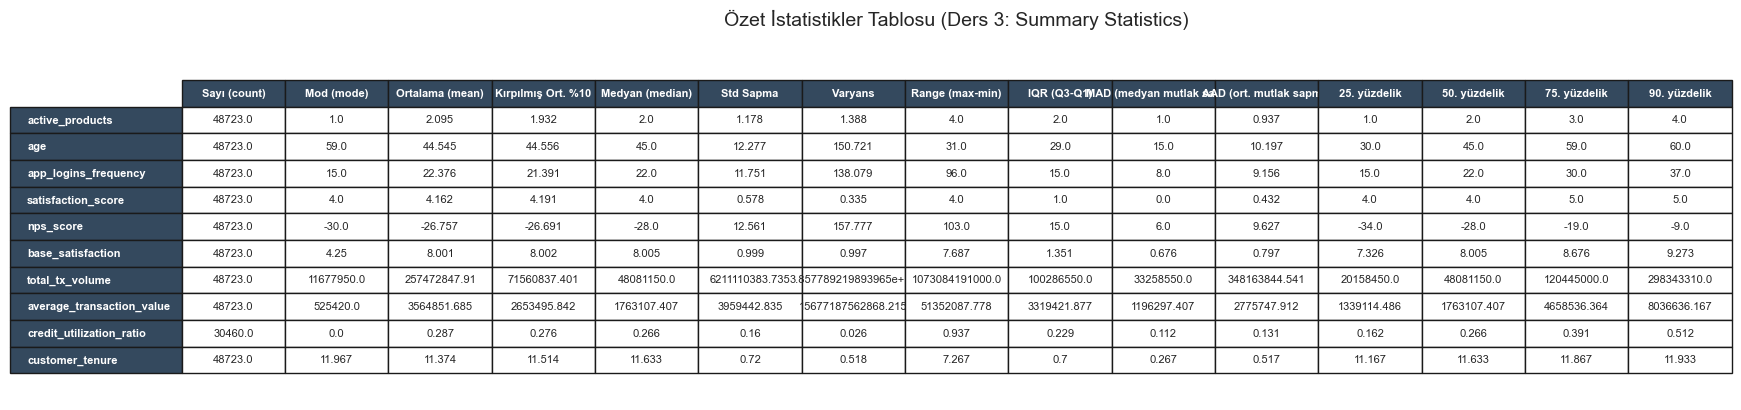

In [11]:
# EDA için anlamlı sayısal öznitelikleri ve sınıf etiketini seçiyoruz
from scipy import stats

eda_features = [
    "active_products", "age", "app_logins_frequency", "satisfaction_score",
    "nps_score", "base_satisfaction", "total_tx_volume",
    "average_transaction_value", "credit_utilization_ratio", "customer_tenure"
]
eda = df[eda_features + ["churn_label"]].copy()
eda["churn_sinifi"] = eda["churn_label"].map({0: "Churn Yok", 1: "Churn Var"})

# --- ÖZET İSTATİSTİKLER (Ders 3: Summary Statistics) ---
def ozet_istatistik(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return pd.Series({
        "Sayı (count)": len(s),
        "Mod (mode)": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "Ortalama (mean)": s.mean(),
        "Kırpılmış Ort. %10": stats.trim_mean(s, 0.10),
        "Medyan (median)": s.median(),
        "Std Sapma": s.std(),
        "Varyans": s.var(),
        "Range (max-min)": s.max() - s.min(),
        "IQR (Q3-Q1)": q3 - q1,
        "MAD (medyan mutlak sapma)": stats.median_abs_deviation(s),
        "AAD (ort. mutlak sapma)": (s - s.mean()).abs().mean(),
        "25. yüzdelik": q1,
        "50. yüzdelik": s.quantile(0.50),
        "75. yüzdelik": q3,
        "90. yüzdelik": s.quantile(0.90),
    })

ozet_tablo = eda[eda_features].apply(ozet_istatistik).T.round(3)
print("=== ÖZET İSTATİSTİKLER (Konum, Yayılma ve Yüzdelikler) ===")
print(ozet_tablo.to_string())

# Tabloyu rapor için görsel olarak da kaydedelim
fig, ax = plt.subplots(figsize=(20, 4.5))
ax.axis("off")
tbl = ax.table(cellText=ozet_tablo.values, rowLabels=ozet_tablo.index,
               colLabels=ozet_tablo.columns, cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0 or c == -1:
        cell.set_facecolor("#34495e"); cell.set_text_props(color="white", weight="bold")
ax.set_title("Özet İstatistikler Tablosu (Ders 3: Summary Statistics)", fontsize=14, pad=20)
plt.savefig(FIG_DIR + "eda_01_ozet_istatistik.png", dpi=200, bbox_inches="tight")
plt.show()

### A.1 Histogramlar (Tek Değişkenli Dağılım)
Her sayısal özniteliğin değerlerinin dağılımını bölmelere (bins) ayırarak gösterir. Ders 3'teki *Petal Width* örneğine benzer şekilde, bölme sayısının (10 vs 20) histogramın şeklini nasıl değiştirdiği de gösterilmiştir.

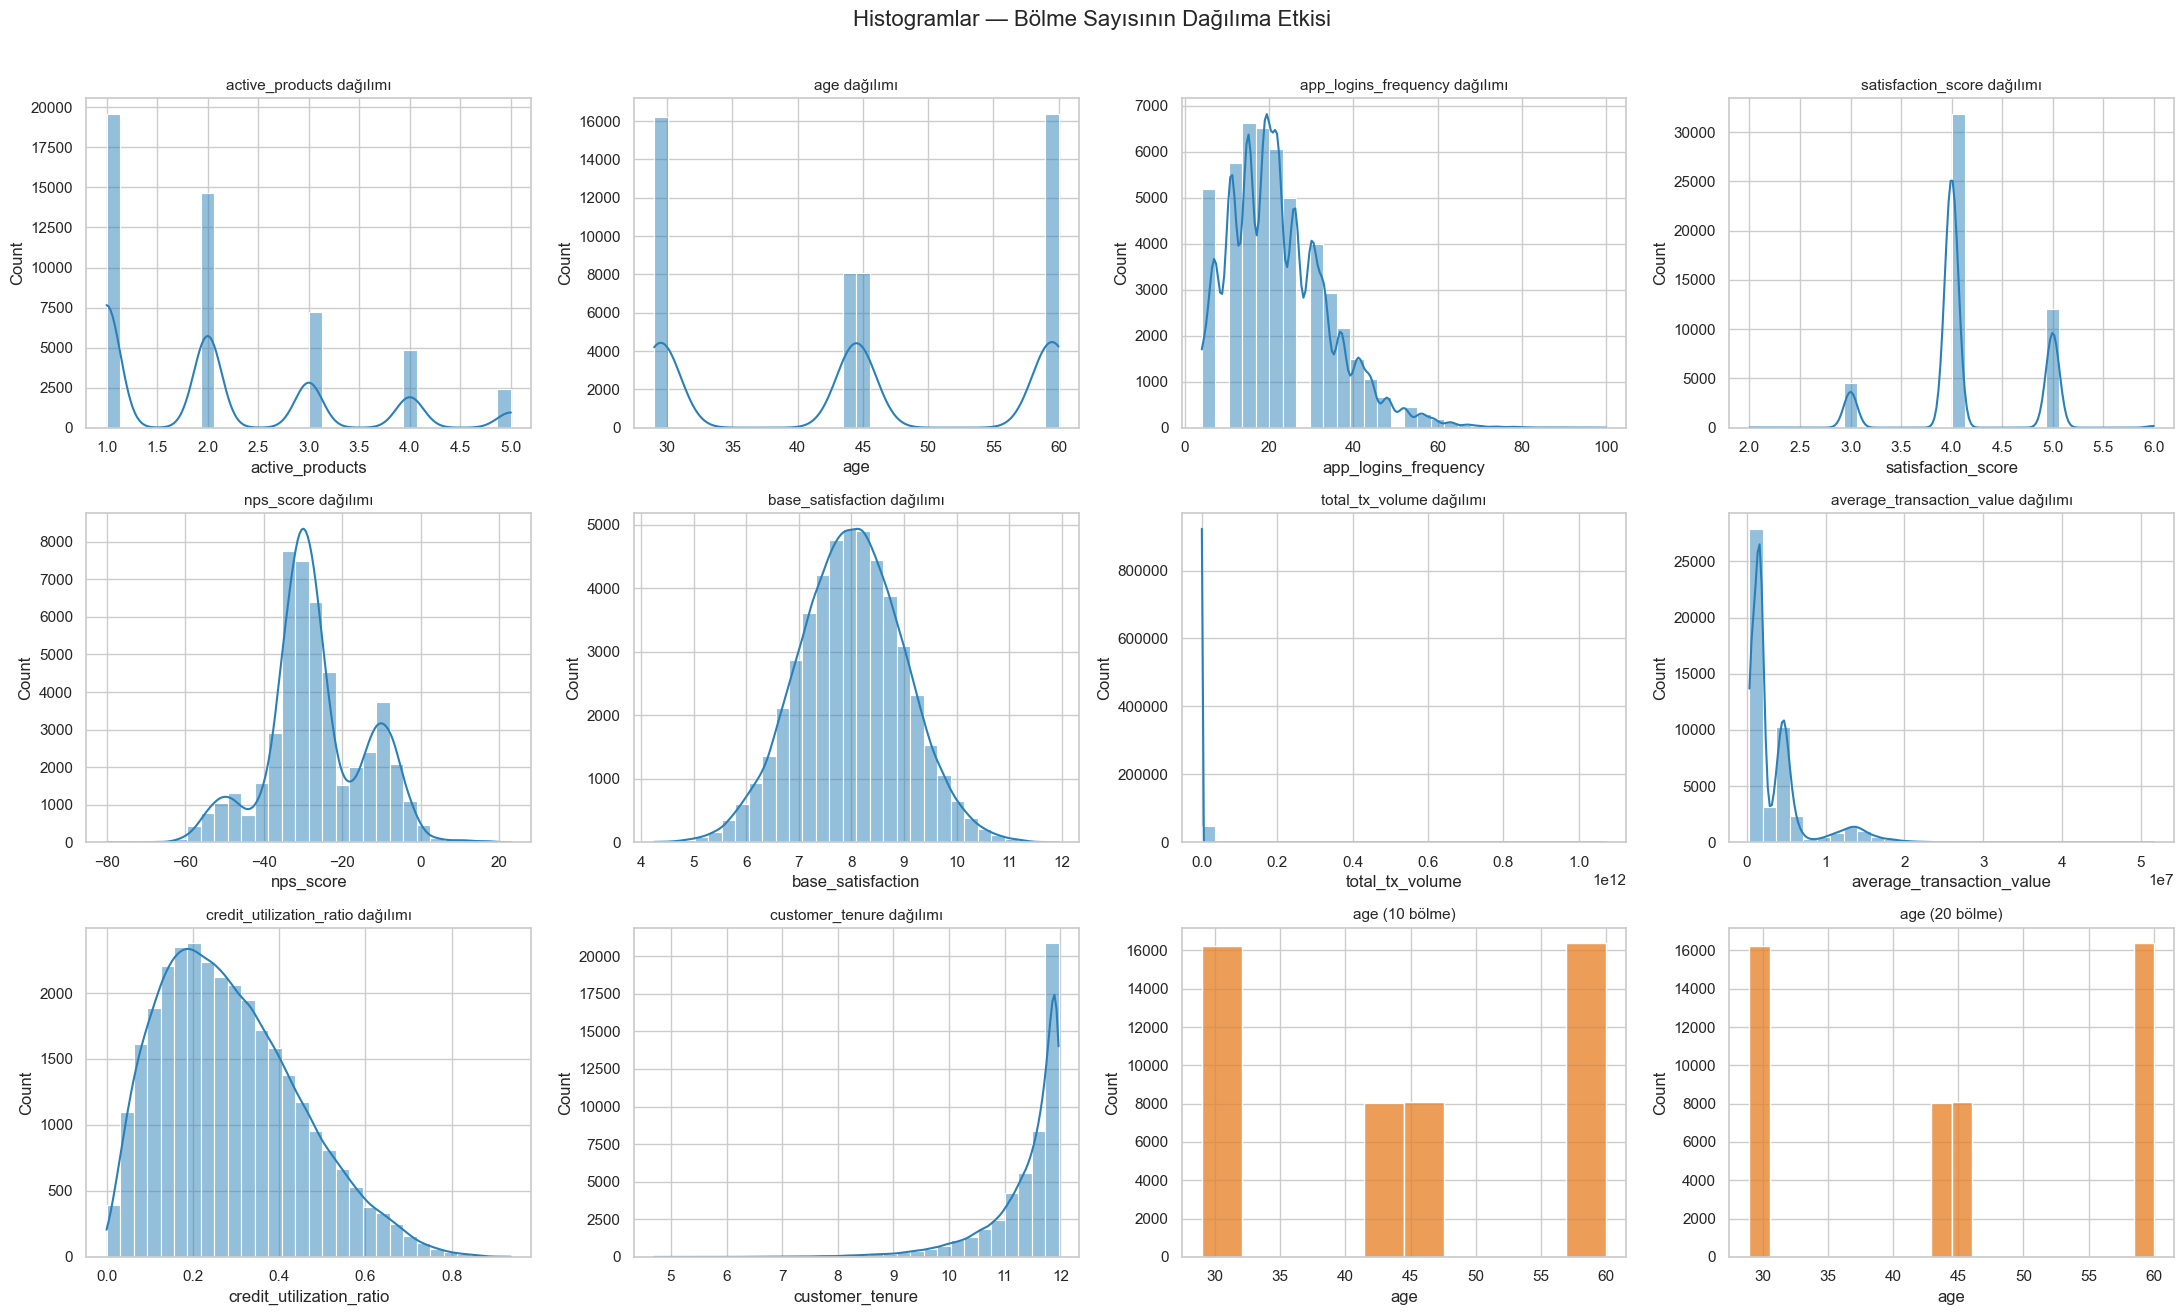

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(22, 13))
axes = axes.ravel()
for i, col in enumerate(eda_features):
    sns.histplot(eda[col].dropna(), bins=30, kde=True, ax=axes[i], color="#2980b9")
    axes[i].set_title(f"{col} dağılımı", fontsize=11)
# Bölme sayısının etkisi (Ders 3 örneği): age -> 10 ve 20 bins
sns.histplot(eda["age"].dropna(), bins=10, ax=axes[10], color="#e67e22")
axes[10].set_title("age (10 bölme)", fontsize=11)
sns.histplot(eda["age"].dropna(), bins=20, ax=axes[11], color="#e67e22")
axes[11].set_title("age (20 bölme)", fontsize=11)
plt.suptitle("Histogramlar — Bölme Sayısının Dağılıma Etkisi", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_02_histogramlar.png", dpi=200, bbox_inches="tight")
plt.show()

### A.2 İki Boyutlu Histogram ve Contour (Yoğunluk) Grafiği
İki özniteliğin **ortak dağılımını (joint distribution)** gösterir. Contour grafiği, düzlemi benzer yoğunluğa sahip bölgelere ayırır (Ders 3'teki SST contour örneğinin veri yoğunluğuna uyarlanmış hali).

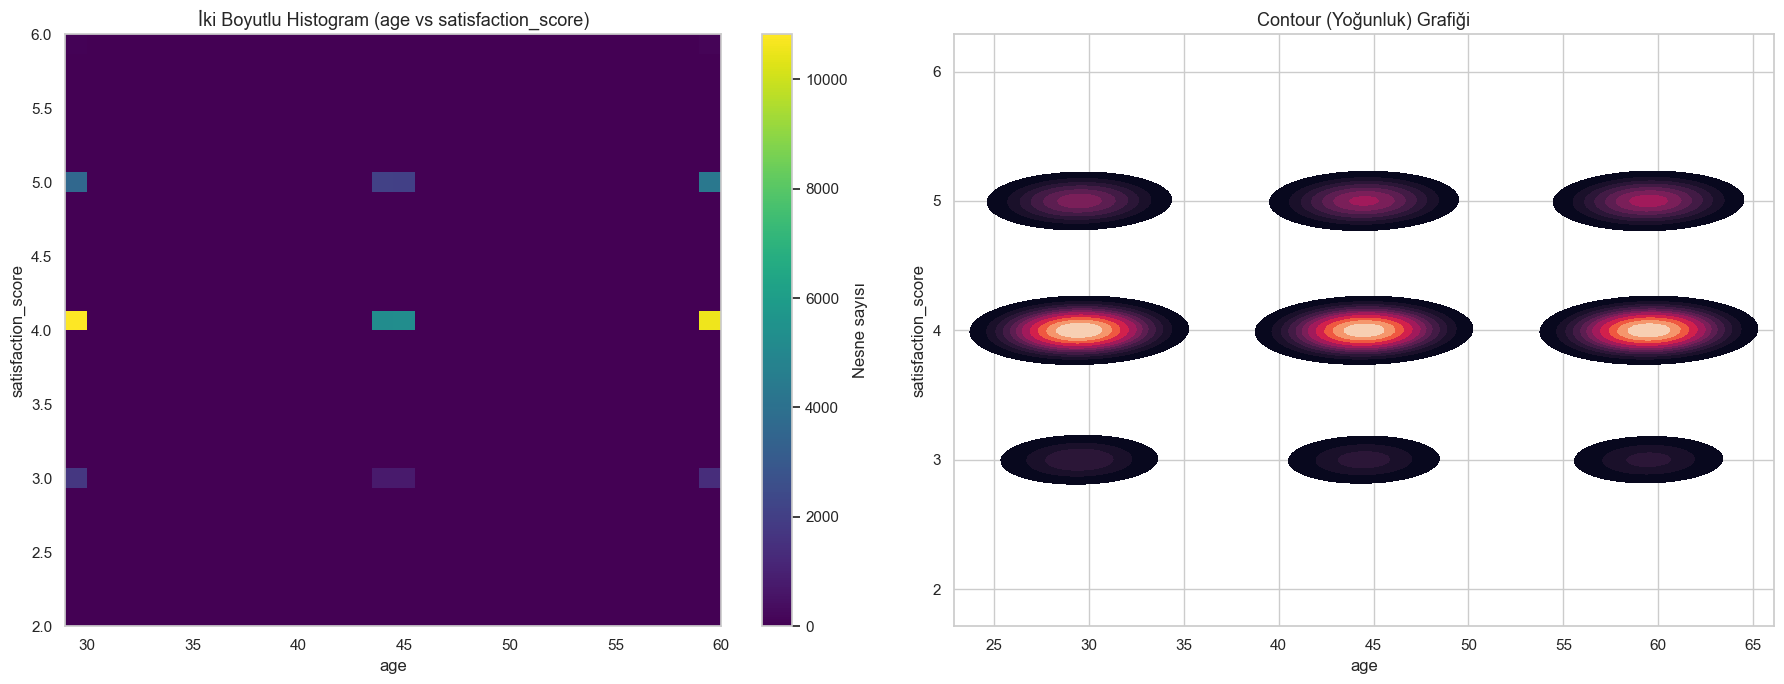

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sub = eda[["age", "satisfaction_score"]].dropna()
hb = axes[0].hist2d(sub["age"], sub["satisfaction_score"], bins=30, cmap="viridis")
fig.colorbar(hb[3], ax=axes[0], label="Nesne sayısı")
axes[0].set_xlabel("age"); axes[0].set_ylabel("satisfaction_score")
axes[0].set_title("İki Boyutlu Histogram (age vs satisfaction_score)", fontsize=13)

sns.kdeplot(data=sub, x="age", y="satisfaction_score", fill=True,
            cmap="rocket", levels=12, ax=axes[1])
axes[1].set_title("Contour (Yoğunluk) Grafiği", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_03_2d_histogram_contour.png", dpi=200, bbox_inches="tight")
plt.show()

### A.3 Pasta Grafikleri (Pie Chart)
Görece az sayıda değere sahip kategorik özniteliklerin **göreceli frekanslarını** gösterir (Ders 3: Pie Chart).

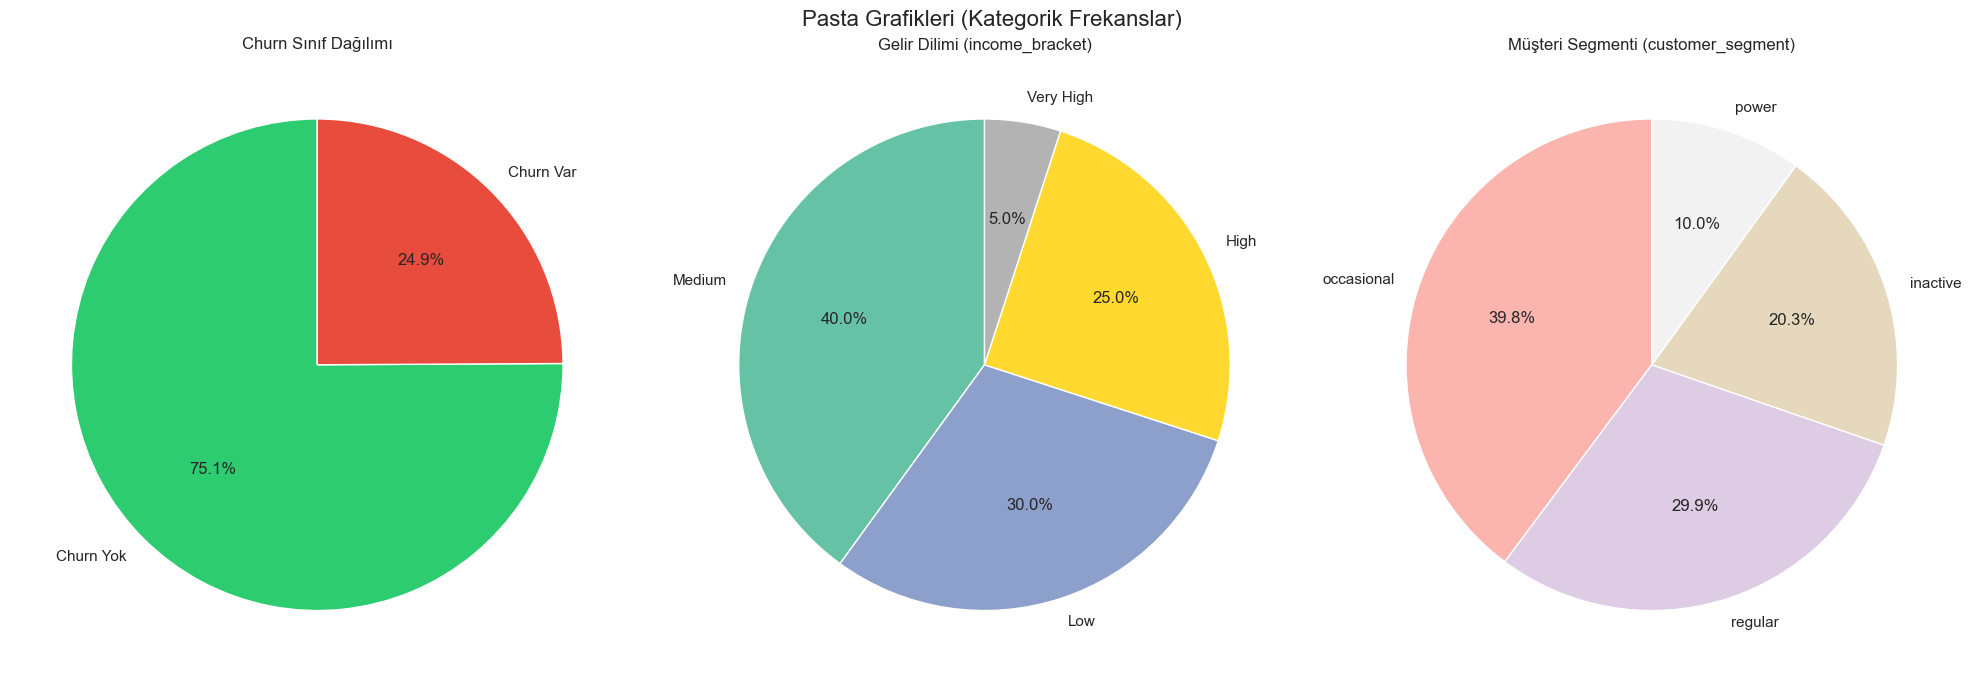

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
# Hedef sınıf dağılımı
eda["churn_sinifi"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0], colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[0].set_title("Churn Sınıf Dağılımı"); axes[0].set_ylabel("")
# Gelir dilimi
df["income_bracket"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], colormap="Set2", startangle=90)
axes[1].set_title("Gelir Dilimi (income_bracket)"); axes[1].set_ylabel("")
# Müşteri segmenti
df["customer_segment"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[2], colormap="Pastel1", startangle=90)
axes[2].set_title("Müşteri Segmenti (customer_segment)"); axes[2].set_ylabel("")
plt.suptitle("Pasta Grafikleri (Kategorik Frekanslar)", fontsize=16)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_04_pasta_grafik.png", dpi=200, bbox_inches="tight")
plt.show()

### A.4 Box Plot (Kutu Grafiği) — J. Tukey
Verinin dağılımını; medyan, çeyrekler (25/75), bıyıklar (whiskers) ve uç değerlerle (outliers) gösterir (Ders 3: Box Plots).

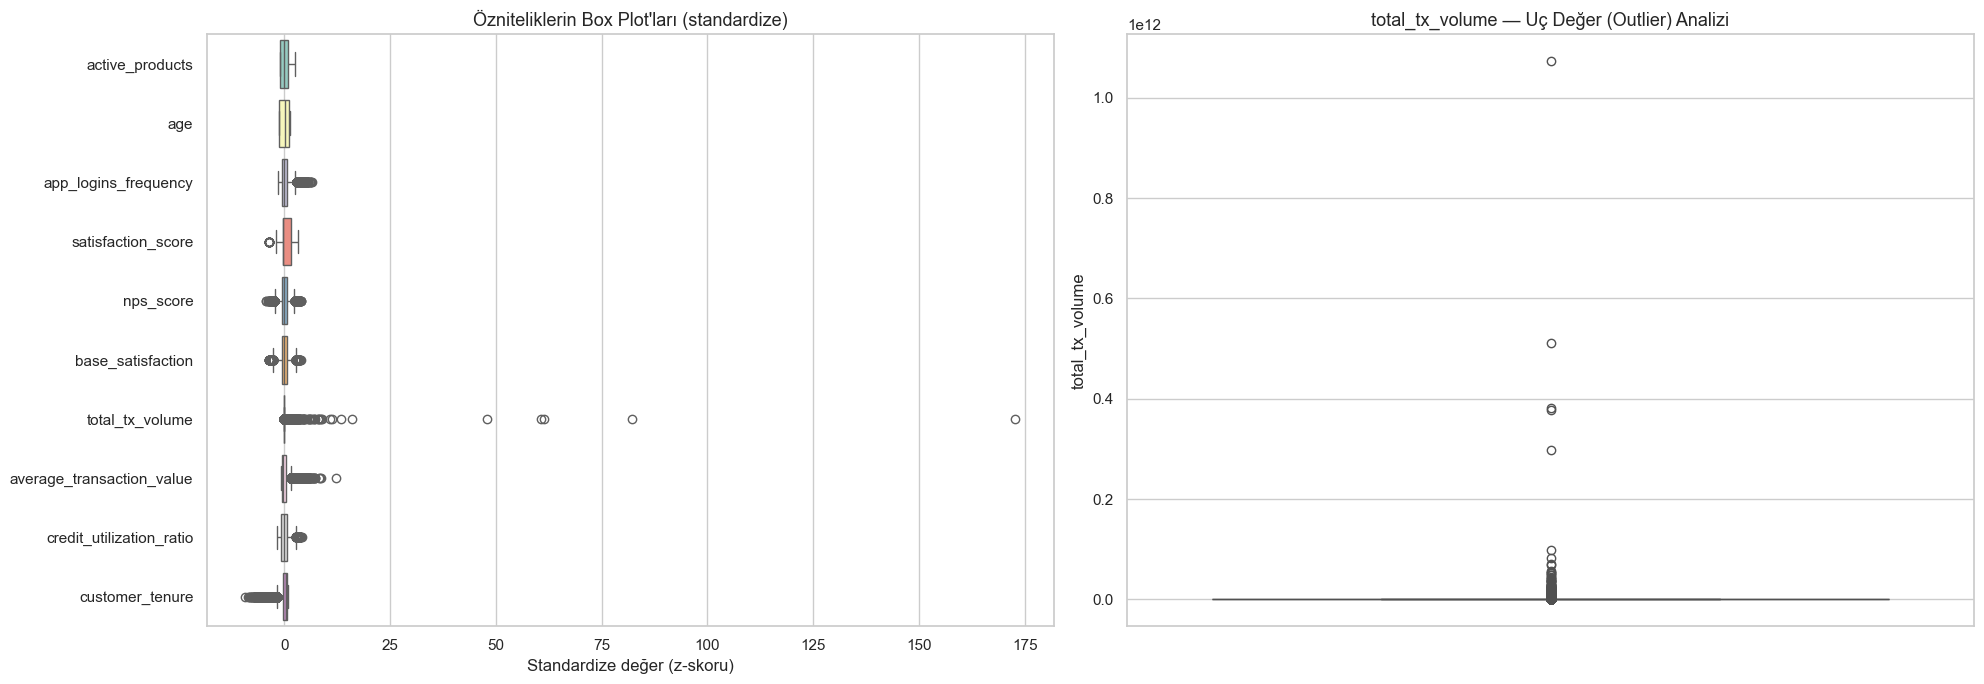

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
# Tüm öznitelikler (standardize edilerek karşılaştırılabilir ölçek)
norm = (eda[eda_features] - eda[eda_features].mean()) / eda[eda_features].std()
sns.boxplot(data=norm, orient="h", palette="Set3", ax=axes[0])
axes[0].set_title("Özniteliklerin Box Plot'ları (standardize)", fontsize=13)
axes[0].set_xlabel("Standardize değer (z-skoru)")
# Tek bir öznitelik üzerinde detay
sns.boxplot(y=eda["total_tx_volume"], color="#3498db", ax=axes[1])
axes[1].set_title("total_tx_volume — Uç Değer (Outlier) Analizi", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_05_box_plots.png", dpi=200, bbox_inches="tight")
plt.show()

### A.5 Sınıfa Göre Box Plot'lar
Ders 3'teki *"Box plots of attributes by Iris species"* örneğine paralel olarak, özniteliklerin **churn sınıfları arasında** nasıl değiştiğini karşılaştırır. Sınıfları ayıran öznitelikler burada net görülür.

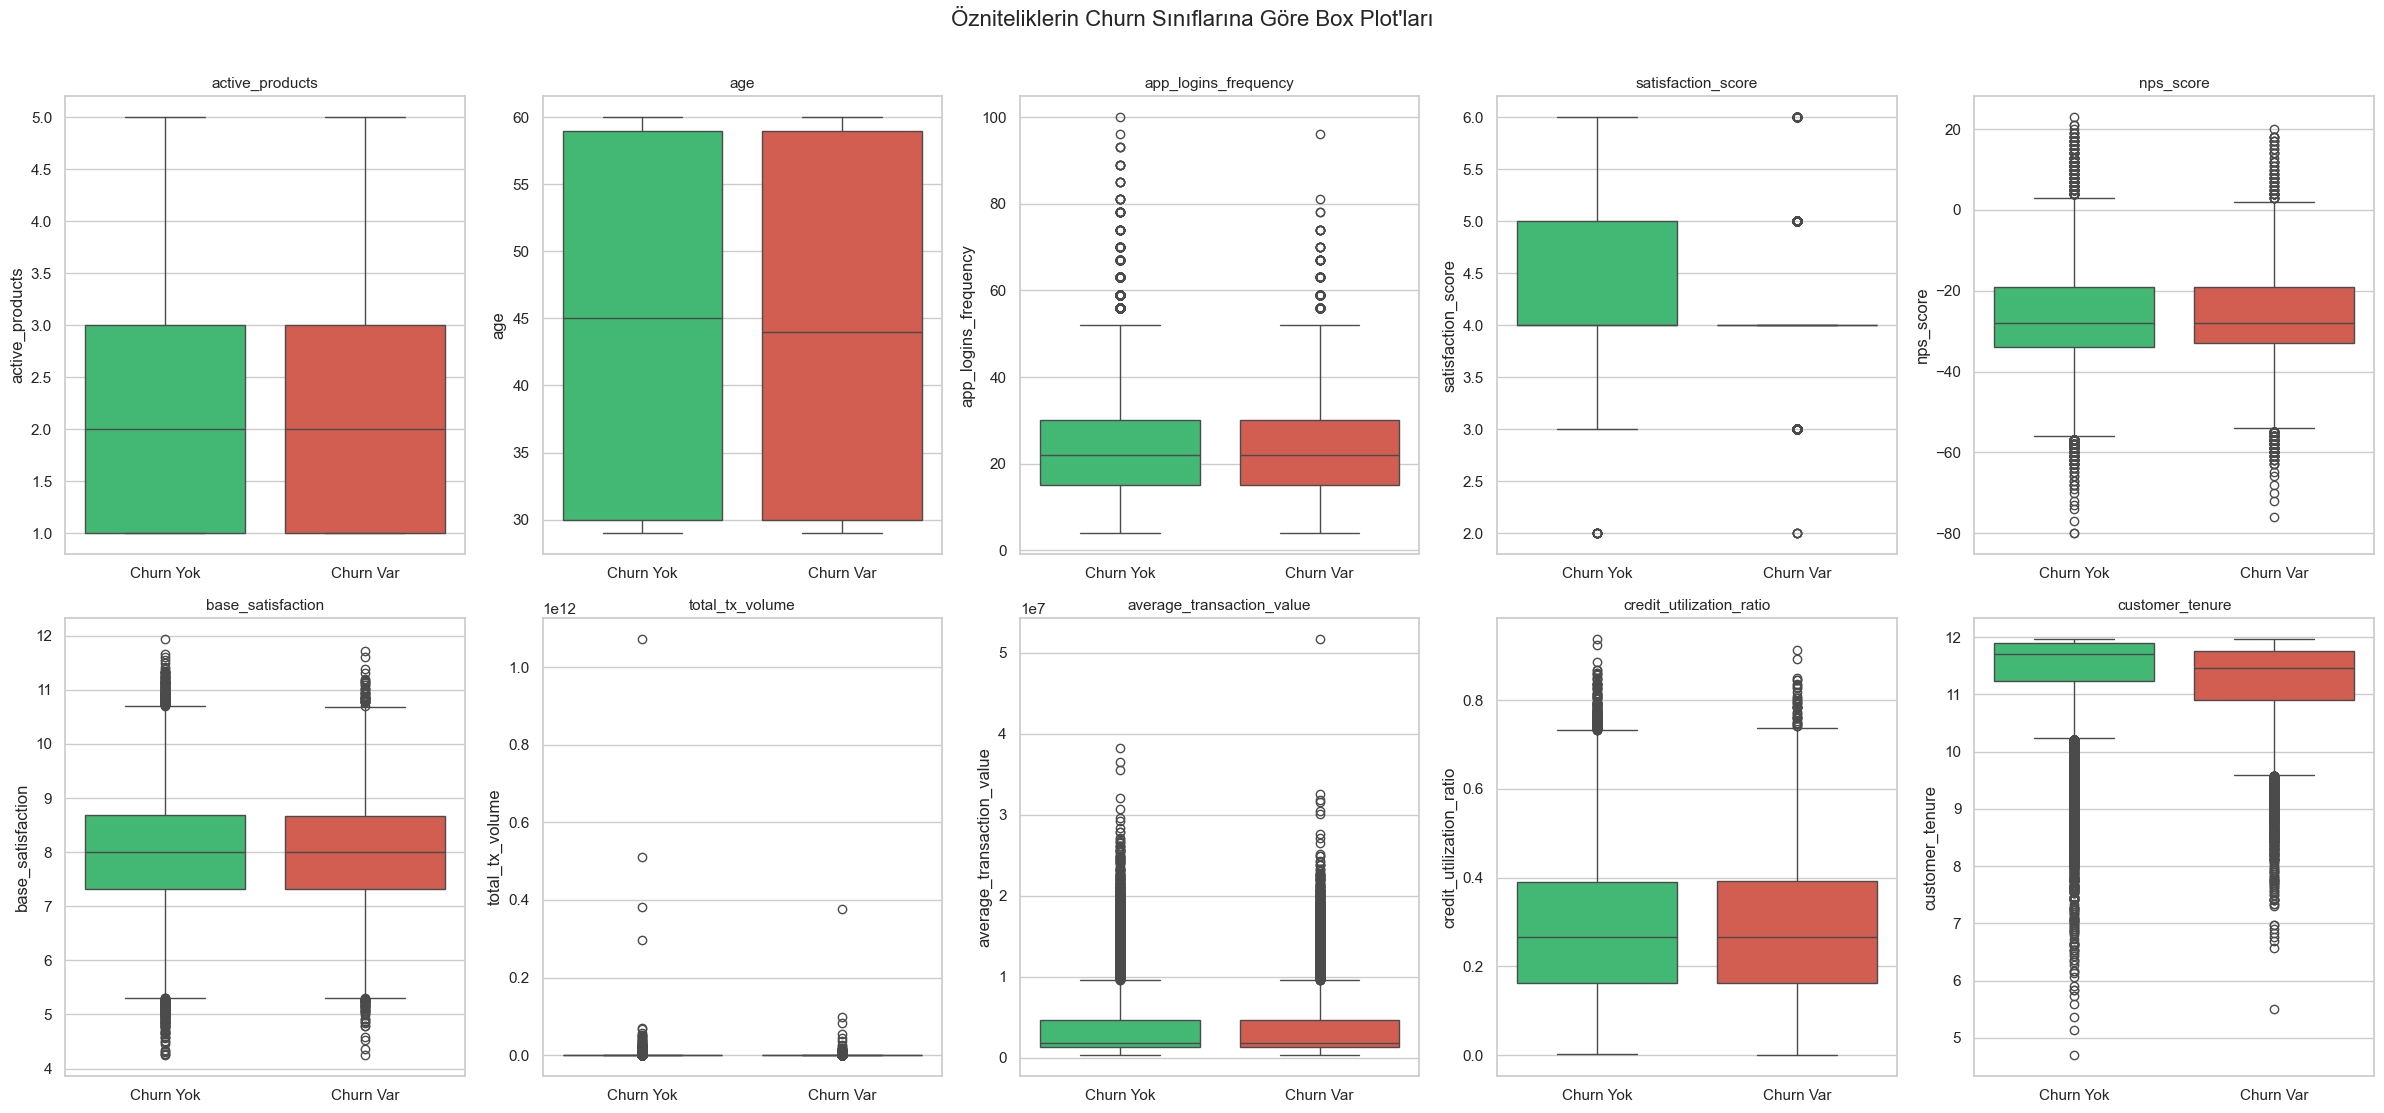

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(24, 11))
axes = axes.ravel()
for i, col in enumerate(eda_features):
    sns.boxplot(data=eda, x="churn_sinifi", y=col, palette=["#2ecc71", "#e74c3c"], ax=axes[i])
    axes[i].set_title(col, fontsize=11); axes[i].set_xlabel("")
plt.suptitle("Özniteliklerin Churn Sınıflarına Göre Box Plot'ları", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_06_box_plots_sinif.png", dpi=200, bbox_inches="tight")
plt.show()

### A.6 Scatter Plot ve Scatter Plot Matrisi
Öznitelik değerleri nokta konumlarını belirler; sınıflar renkle gösterilir. Scatter matrisi, birçok öznitelik çiftinin ilişkisini kompakt biçimde özetler (Ders 3: Scatter Plots / Scatter Plot Array).

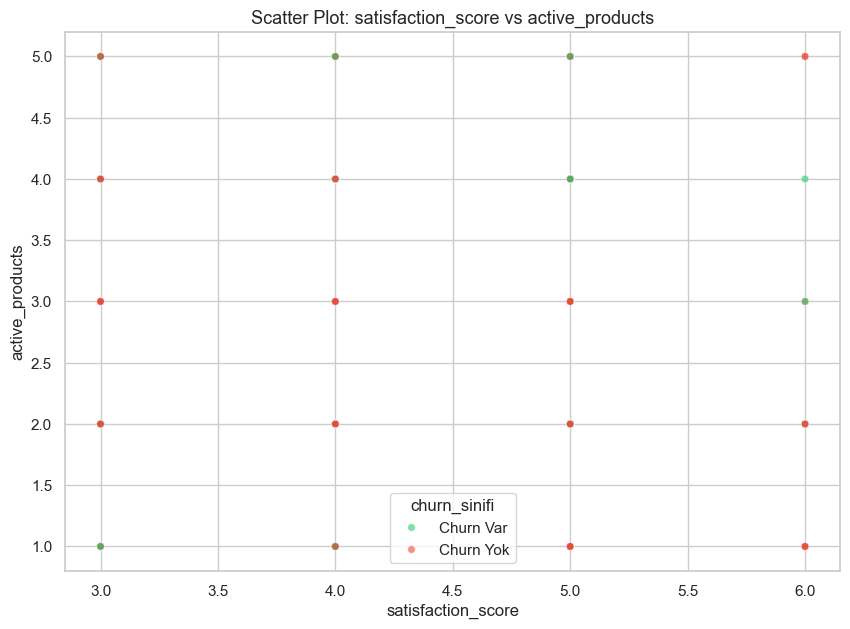

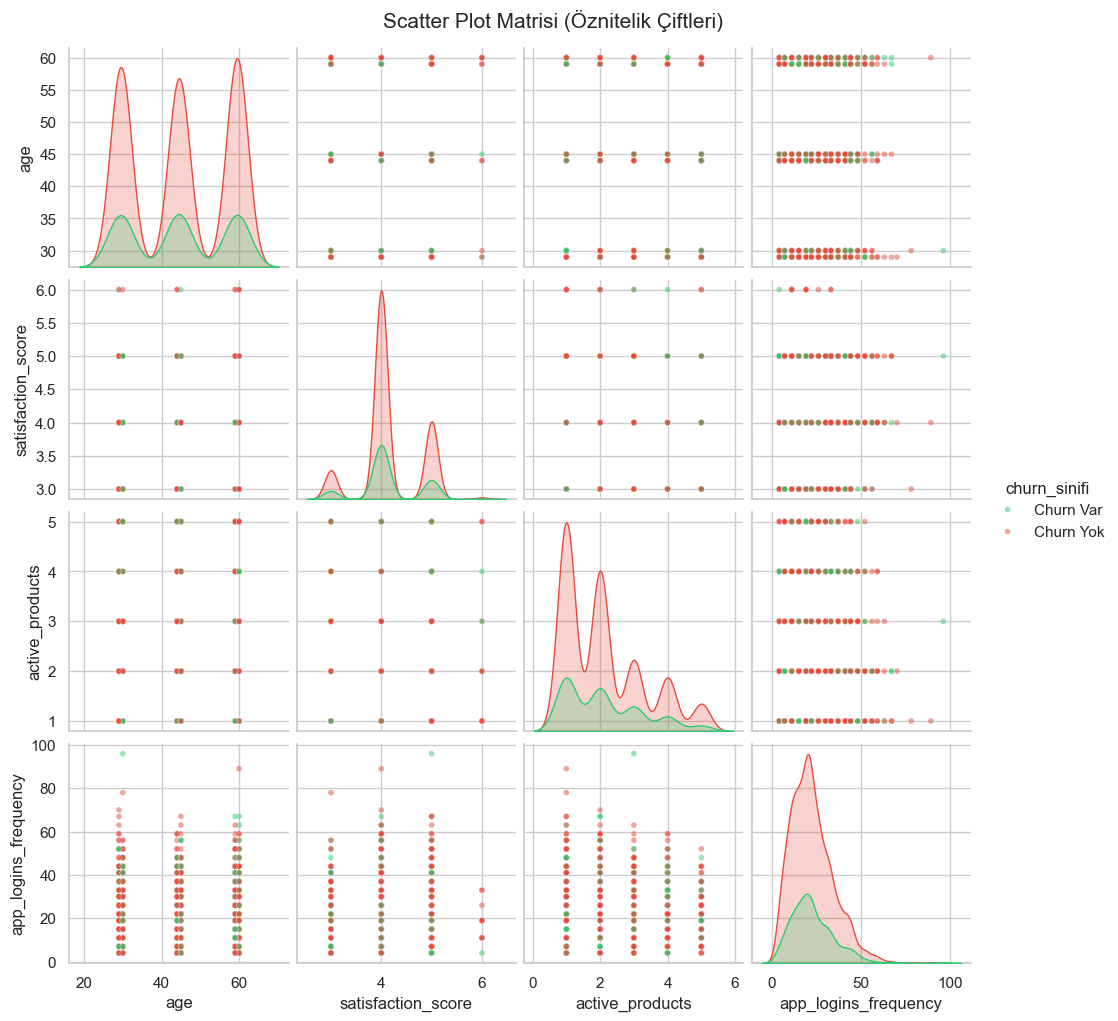

In [17]:
# Görsel netlik için örneklem alıyoruz (48k nokta çok kalabalık olur)
sample = eda.dropna(subset=["age", "satisfaction_score", "active_products",
                            "app_logins_frequency"]).sample(
    n=min(2500, len(eda)), random_state=42)

# Tekli scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample, x="satisfaction_score", y="active_products",
                hue="churn_sinifi", palette=["#2ecc71", "#e74c3c"], alpha=0.6, s=30)
plt.title("Scatter Plot: satisfaction_score vs active_products", fontsize=13)
plt.savefig(FIG_DIR + "eda_07_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

# Scatter plot matrisi (pairplot)
pp = sns.pairplot(
    sample[["age", "satisfaction_score", "active_products", "app_logins_frequency", "churn_sinifi"]],
    hue="churn_sinifi", palette=["#2ecc71", "#e74c3c"], diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 18})
pp.fig.suptitle("Scatter Plot Matrisi (Öznitelik Çiftleri)", y=1.02, fontsize=15)
pp.savefig(FIG_DIR + "eda_08_scatter_matrix.png", dpi=180)
plt.show()

### A.7 Matrix Plot ve Korelasyon Matrisi
**Matrix Plot:** Nesneler sınıfa göre sıralanır ve standardize edilmiş veri matrisi bir görüntü olarak çizilir (Ders 3: Visualization of the Iris Data Matrix). **Korelasyon Matrisi:** Öznitelikler arası ilişkileri ısı haritası ile gösterir.

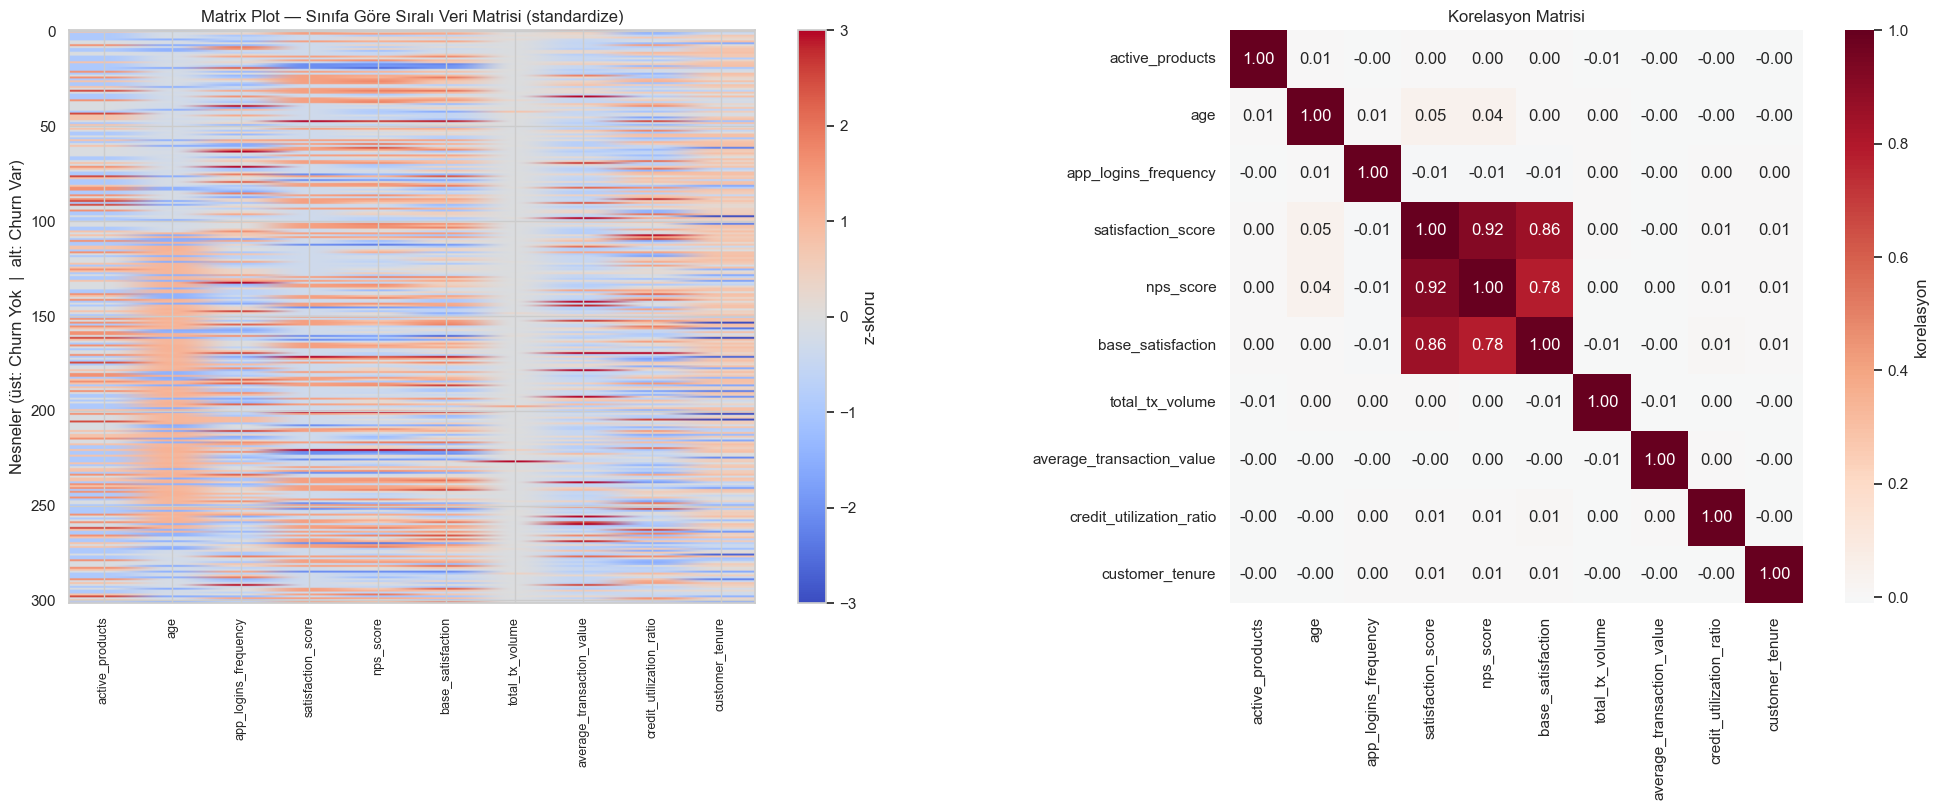

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Matrix Plot: sınıfa göre sıralı, standardize veri matrisi ---
mat = eda.dropna(subset=eda_features).sort_values("churn_label")
mat_std = (mat[eda_features] - mat[eda_features].mean()) / mat[eda_features].std()
mat_sample = mat_std.iloc[::max(1, len(mat_std)//300)]  # ~300 satıra indir
im = axes[0].imshow(mat_sample.values, aspect="auto", cmap="coolwarm", vmin=-3, vmax=3)
axes[0].set_xticks(range(len(eda_features)))
axes[0].set_xticklabels(eda_features, rotation=90, fontsize=9)
axes[0].set_ylabel("Nesneler (üst: Churn Yok  |  alt: Churn Var)")
axes[0].set_title("Matrix Plot — Sınıfa Göre Sıralı Veri Matrisi (standardize)", fontsize=12)
fig.colorbar(im, ax=axes[0], label="z-skoru")

# --- Korelasyon matrisi ---
corr = eda[eda_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=axes[1], cbar_kws={"label": "korelasyon"})
axes[1].set_title("Korelasyon Matrisi", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_09_matrix_korelasyon.png", dpi=200, bbox_inches="tight")
plt.show()

### A.8 Paralel Koordinatlar (Parallel Coordinates)
Yüksek boyutlu verinin öznitelik değerlerini paralel eksenlerde çizer; her nesne bir çizgi olur. Aynı sınıfa ait çizgilerin gruplanması, sınıfları ayıran öznitelikleri ortaya koyar (Ders 3: Parallel Coordinates).

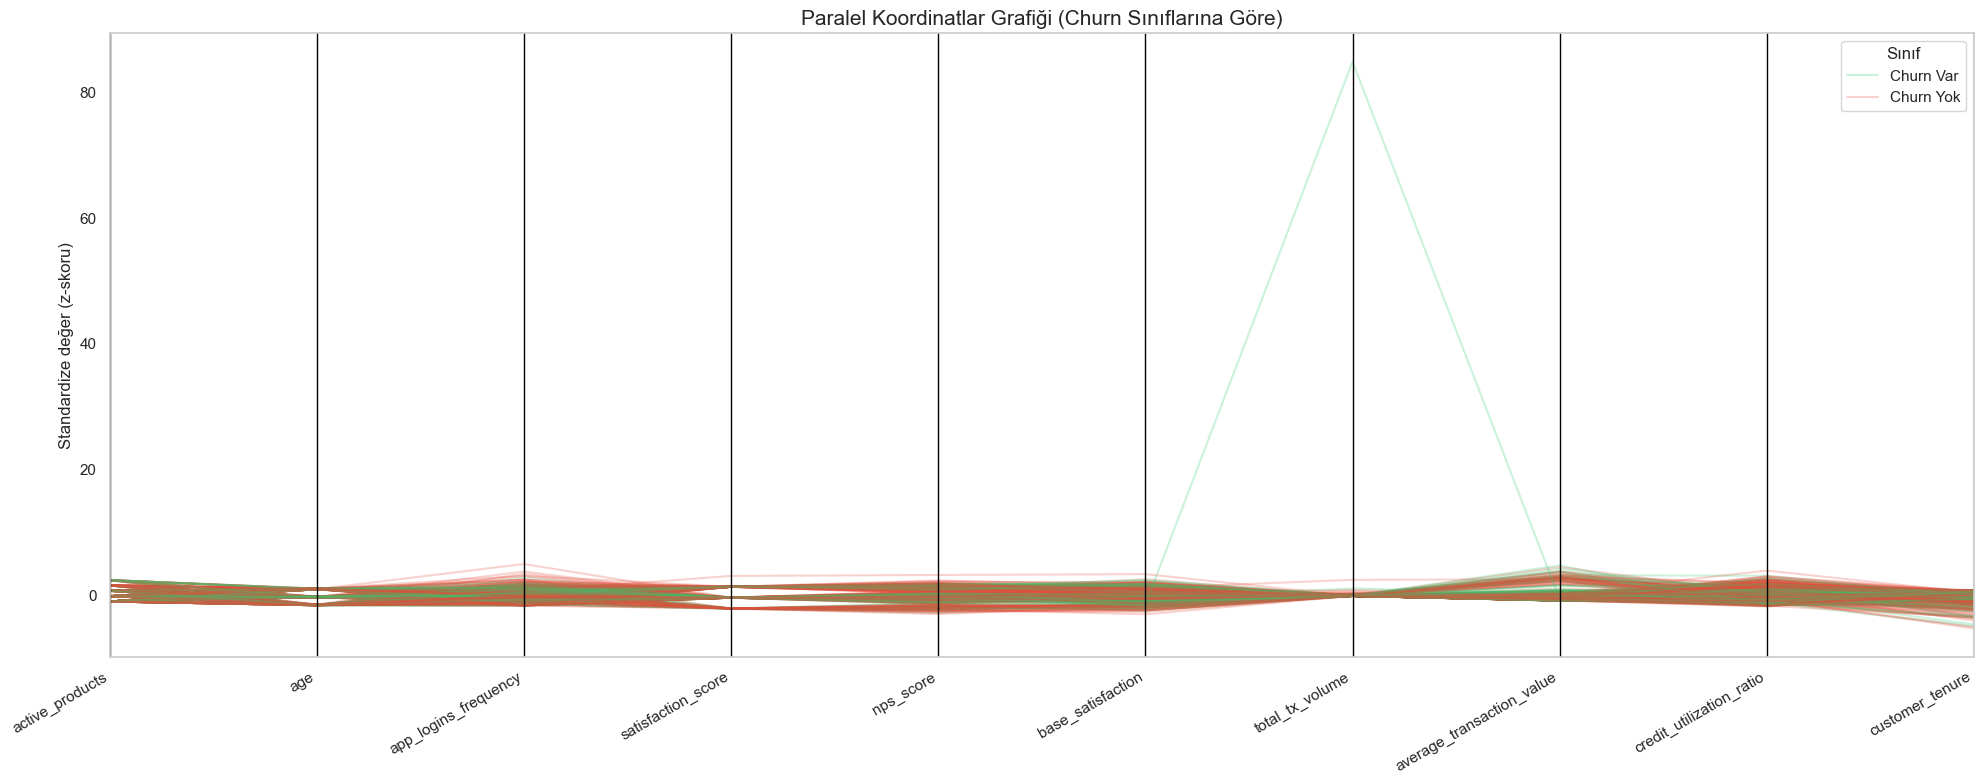

In [19]:
from pandas.plotting import parallel_coordinates

pc = eda.dropna(subset=eda_features).copy()
pc_std = pc.copy()
pc_std[eda_features] = (pc[eda_features] - pc[eda_features].mean()) / pc[eda_features].std()
pc_std = pc_std.sample(n=min(600, len(pc_std)), random_state=42)

plt.figure(figsize=(20, 8))
parallel_coordinates(pc_std[eda_features + ["churn_sinifi"]], "churn_sinifi",
                     color=["#2ecc71", "#e74c3c"], alpha=0.25)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Standardize değer (z-skoru)")
plt.title("Paralel Koordinatlar Grafiği (Churn Sınıflarına Göre)", fontsize=15)
plt.legend(title="Sınıf")
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_10_paralel_koordinatlar.png", dpi=200, bbox_inches="tight")
plt.show()

### A.9 Yıldız (Star / Radar) Grafikleri
Her öznitelik için merkezi bir noktadan yayılan bir eksen kullanılır; nesnenin değerlerini birleştiren çizgi bir çokgen oluşturur. Ders 3'teki *Star Plots for Iris Data* örneğine paralel olarak her churn sınıfının ortalama profili çizilmiştir.

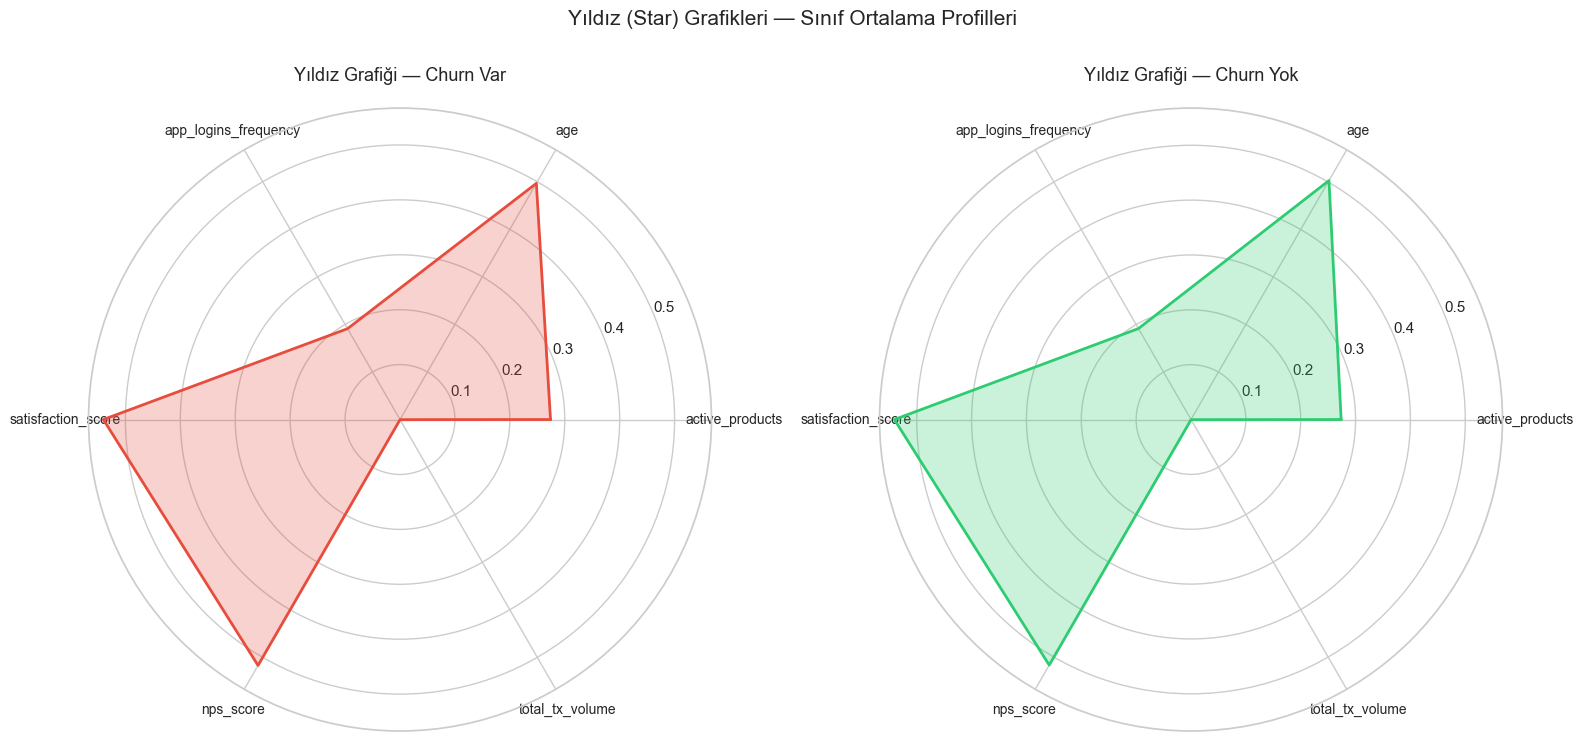

In [20]:
star_feats = ["active_products", "age", "app_logins_frequency",
              "satisfaction_score", "nps_score", "total_tx_volume"]
# Sınıf ortalamalarını [0,1] aralığına ölçekle
means = eda.groupby("churn_sinifi")[star_feats].mean()
scaled = (means - eda[star_feats].min()) / (eda[star_feats].max() - eda[star_feats].min())

angles = np.linspace(0, 2*np.pi, len(star_feats), endpoint=False).tolist()
angles += angles[:1]
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(polar=True))
colors = {"Churn Yok": "#2ecc71", "Churn Var": "#e74c3c"}
for ax, (cls, row) in zip(axes, scaled.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=colors[cls], linewidth=2)
    ax.fill(angles, vals, color=colors[cls], alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(star_feats, fontsize=10)
    ax.set_title(f"Yıldız Grafiği — {cls}", fontsize=13, pad=20)
plt.suptitle("Yıldız (Star) Grafikleri — Sınıf Ortalama Profilleri", fontsize=15)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_11_yildiz_grafik.png", dpi=200, bbox_inches="tight")
plt.show()

### A.10 Chernoff Yüzleri
Herman Chernoff'un yaklaşımı her özniteliği bir yüz özelliğiyle eşler; insanın yüzleri ayırt etme yeteneğinden yararlanır (Ders 3: Chernoff Faces). Aşağıda her churn sınıfının ortalama profili bir yüz olarak çizilmiştir.

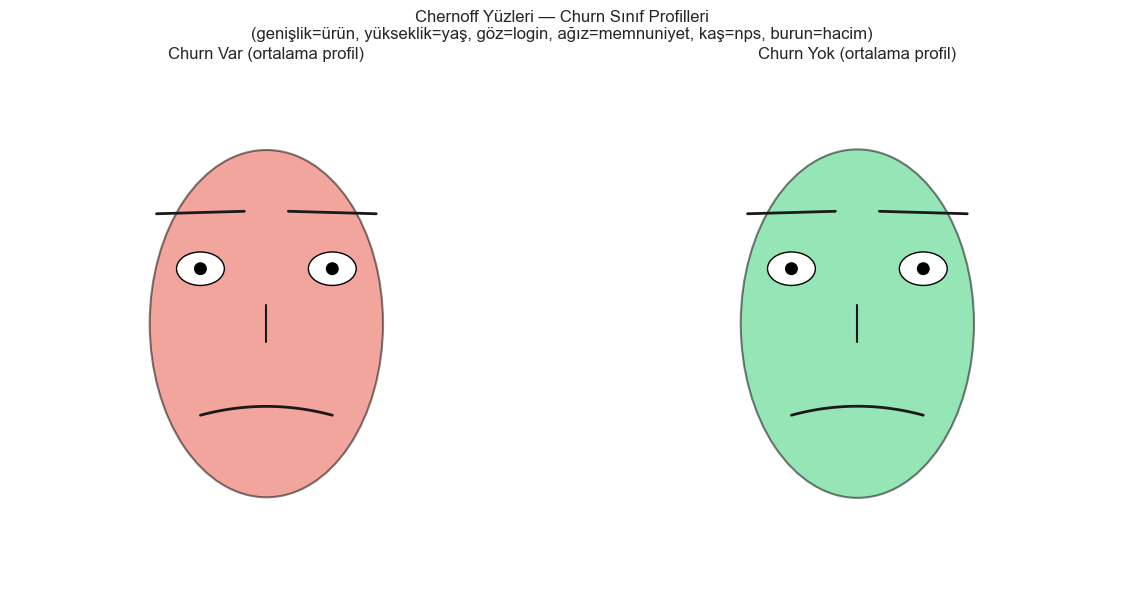

In [21]:
from matplotlib.patches import Ellipse, Arc

def chernoff_face(ax, p, title, fc):
    # p: 6 öznitelik [0,1] ölçekli -> yüz özellikleri
    yuz_g, yuz_y = 0.5 + p[0]*0.5, 0.7 + p[1]*0.5      # yüz genişlik/yükseklik
    goz_b = 0.05 + p[2]*0.08                            # göz boyutu
    agiz_egri = (p[3]-0.5)*0.6                          # ağız eğriliği (gülümseme)
    kas_egim = (p[4]-0.5)*0.4                           # kaş eğimi
    burun = 0.1 + p[5]*0.25                             # burun uzunluğu
    ax.add_patch(Ellipse((0,0), yuz_g, yuz_y, fc=fc, ec="black", lw=1.5, alpha=0.5))
    for sx in (-1, 1):  # gözler
        ax.add_patch(Ellipse((sx*0.18, 0.15), goz_b*2, goz_b*1.4, fc="white", ec="black"))
        ax.add_patch(Ellipse((sx*0.18, 0.15), goz_b*0.6, goz_b*0.6, fc="black"))
        ax.plot([sx*0.30, sx*0.06], [0.30+kas_egim*sx*0, 0.30+kas_egim], "k-", lw=2)  # kaş
    ax.plot([0, 0], [0.05, 0.05-burun], "k-", lw=1.5)   # burun
    xs = np.linspace(-0.18, 0.18, 30)                   # ağız
    ax.plot(xs, -0.25 + agiz_egri*(1-(xs/0.18)**2), "k-", lw=2)
    ax.set_xlim(-0.7, 0.7); ax.set_ylim(-0.7, 0.7); ax.set_aspect("equal")
    ax.axis("off"); ax.set_title(title, fontsize=12)

face_feats = ["active_products", "age", "app_logins_frequency",
              "satisfaction_score", "nps_score", "total_tx_volume"]
fmeans = eda.groupby("churn_sinifi")[face_feats].mean()
fscaled = (fmeans - eda[face_feats].min()) / (eda[face_feats].max() - eda[face_feats].min())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
cmap = {"Churn Yok": "#2ecc71", "Churn Var": "#e74c3c"}
for ax, (cls, row) in zip(axes, fscaled.iterrows()):
    chernoff_face(ax, row.values, f"{cls} (ortalama profil)", cmap[cls])
plt.suptitle("Chernoff Yüzleri — Churn Sınıf Profilleri\n"
             "(genişlik=ürün, yükseklik=yaş, göz=login, ağız=memnuniyet, kaş=nps, burun=hacim)",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + "eda_12_chernoff.png", dpi=200, bbox_inches="tight")
plt.show()

---
# EK BÖLÜM B — Genişletilmiş Model Başarı Metrikleri
Mevcut Accuracy / Precision / Recall / F1 / ROC-AUC metriklerine ek olarak, sınıflandırma başarısını farklı açılardan ölçen ileri metrikler eklenmiştir.

In [22]:
from sklearn.metrics import (balanced_accuracy_score, cohen_kappa_score,
    matthews_corrcoef, log_loss, brier_score_loss, average_precision_score,
    precision_recall_fscore_support)

bal_acc = balanced_accuracy_score(y_test, y_pred)
kappa   = cohen_kappa_score(y_test, y_pred)
mcc     = matthews_corrcoef(y_test, y_pred)
ll      = log_loss(y_test, y_proba)
brier   = brier_score_loss(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)
npv     = tn / (tn + fn)        # Negatif kestirim değeri
fpr_v   = fp / (fp + tn)        # Yanlış pozitif oranı
fnr_v   = fn / (fn + tp)        # Yanlış negatif oranı

ek_metrikler = pd.DataFrame({
    "Metrik": ["Dengeli Doğruluk (Balanced Acc.)", "Cohen's Kappa",
               "Matthews Korelasyon Katsayısı (MCC)", "Log Loss (düşük=iyi)",
               "Brier Skoru (düşük=iyi)", "Ortalama Kesinlik (PR-AUC)",
               "Negatif Kestirim Değeri (NPV)", "Yanlış Pozitif Oranı (FPR)",
               "Yanlış Negatif Oranı (FNR)"],
    "Değer": [bal_acc, kappa, mcc, ll, brier, ap, npv, fpr_v, fnr_v]
})
print("=== EK MODEL BAŞARI METRİKLERİ ===")
print(ek_metrikler.round(4).to_string(index=False))

# Sınıf bazlı detaylı metrikler
prec, rec, f1s, sup = precision_recall_fscore_support(y_test, y_pred)
sinif_tablo = pd.DataFrame({
    "Sınıf": ["Churn Yok (0)", "Churn Var (1)"],
    "Precision": prec, "Recall": rec, "F1": f1s, "Destek (support)": sup
})
print("\n=== SINIF BAZLI METRİKLER ===")
print(sinif_tablo.round(4).to_string(index=False))

=== EK MODEL BAŞARI METRİKLERİ ===
                             Metrik  Değer
   Dengeli Doğruluk (Balanced Acc.) 0.6938
                      Cohen's Kappa 0.2998
Matthews Korelasyon Katsayısı (MCC) 0.3360
               Log Loss (düşük=iyi) 0.5826
            Brier Skoru (düşük=iyi) 0.2062
         Ortalama Kesinlik (PR-AUC) 0.4248
      Negatif Kestirim Değeri (NPV) 0.8870
         Yanlış Pozitif Oranı (FPR) 0.3711
         Yanlış Negatif Oranı (FNR) 0.2414

=== SINIF BAZLI METRİKLER ===
        Sınıf  Precision  Recall     F1  Destek (support)
Churn Yok (0)     0.8870  0.6289 0.7360              7317
Churn Var (1)     0.4042  0.7586 0.5274              2428


### B.1 İleri Değerlendirme Grafikleri
**Precision-Recall Eğrisi**, **Kalibrasyon Eğrisi** (tahmin olasılıklarının güvenilirliği), **Eşik (Threshold) Analizi** ve **Öğrenme Eğrisi (Learning Curve)** ile model davranışı çok yönlü incelenmiştir.

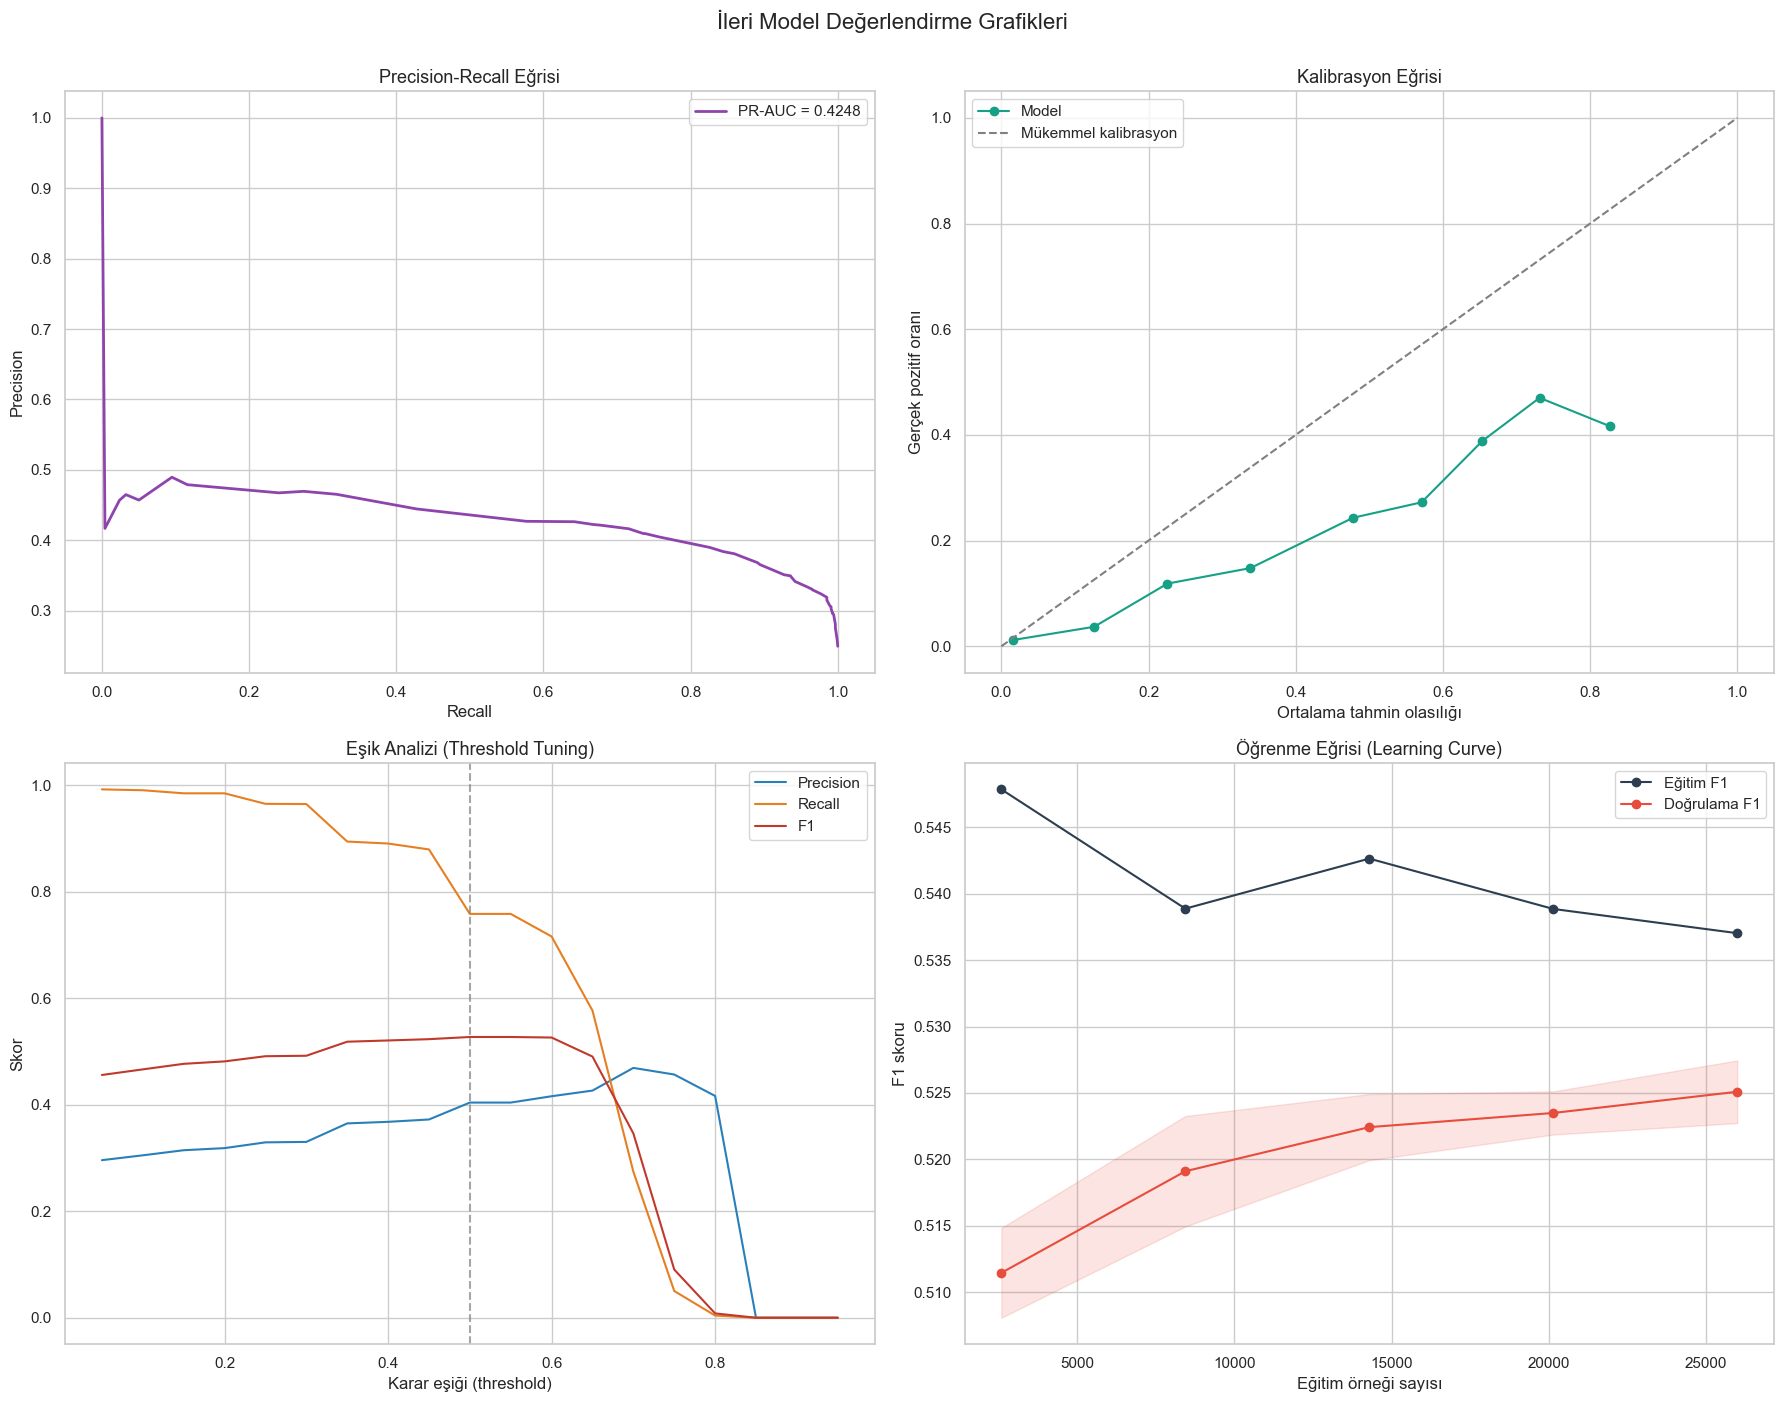

In [23]:
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Precision-Recall Eğrisi
pr_p, pr_r, _ = precision_recall_curve(y_test, y_proba)
axes[0,0].plot(pr_r, pr_p, color="#8e44ad", lw=2, label=f"PR-AUC = {ap:.4f}")
axes[0,0].set_xlabel("Recall"); axes[0,0].set_ylabel("Precision")
axes[0,0].set_title("Precision-Recall Eğrisi", fontsize=13); axes[0,0].legend()

# 2. Kalibrasyon Eğrisi
frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[0,1].plot(mean_pred, frac_pos, "o-", color="#16a085", label="Model")
axes[0,1].plot([0,1],[0,1], "--", color="gray", label="Mükemmel kalibrasyon")
axes[0,1].set_xlabel("Ortalama tahmin olasılığı"); axes[0,1].set_ylabel("Gerçek pozitif oranı")
axes[0,1].set_title("Kalibrasyon Eğrisi", fontsize=13); axes[0,1].legend()

# 3. Eşik (Threshold) Analizi
ths = np.linspace(0.05, 0.95, 19)
pr_list, rc_list, f1_list = [], [], []
for t in ths:
    yp = (y_proba >= t).astype(int)
    pr_list.append(precision_score(y_test, yp, zero_division=0))
    rc_list.append(recall_score(y_test, yp, zero_division=0))
    f1_list.append(f1_score(y_test, yp, zero_division=0))
axes[1,0].plot(ths, pr_list, label="Precision", color="#2980b9")
axes[1,0].plot(ths, rc_list, label="Recall", color="#e67e22")
axes[1,0].plot(ths, f1_list, label="F1", color="#c0392b")
axes[1,0].axvline(0.5, ls="--", color="gray", alpha=0.7)
axes[1,0].set_xlabel("Karar eşiği (threshold)"); axes[1,0].set_ylabel("Skor")
axes[1,0].set_title("Eşik Analizi (Threshold Tuning)", fontsize=13); axes[1,0].legend()

# 4. Öğrenme Eğrisi (Learning Curve)
ts, tr_sc, te_sc = learning_curve(best_model, X_train, y_train, cv=3,
    scoring="f1", train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1, random_state=42)
axes[1,1].plot(ts, tr_sc.mean(1), "o-", color="#2c3e50", label="Eğitim F1")
axes[1,1].plot(ts, te_sc.mean(1), "o-", color="#e74c3c", label="Doğrulama F1")
axes[1,1].fill_between(ts, te_sc.mean(1)-te_sc.std(1), te_sc.mean(1)+te_sc.std(1), alpha=0.15, color="#e74c3c")
axes[1,1].set_xlabel("Eğitim örneği sayısı"); axes[1,1].set_ylabel("F1 skoru")
axes[1,1].set_title("Öğrenme Eğrisi (Learning Curve)", fontsize=13); axes[1,1].legend()

plt.suptitle("İleri Model Değerlendirme Grafikleri", fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig(FIG_DIR + "model_ek_metrikler.png", dpi=200, bbox_inches="tight")
plt.show()

---
# EK BÖLÜM C — Baseline (Taban) Model Karşılaştırması
Karar Ağacı'nın başarısını bir referansa göre değerlendirebilmek için, aynı ön işleme (Pipeline) ile basit taban modeller eğitilip karşılaştırılmıştır:
- **Dummy:** Her müşteriye "kalır" diyen naif taban (alt sınır).
- **Lojistik Regresyon** ve **Naive Bayes:** Klasik temel sınıflandırıcılar.

Bu karşılaştırma, "Neden Karar Ağacı?" sorusuna nesnel bir yanıt verir.

=== BASELINE MODEL KARŞILAŞTIRMASI ===
                    Model  Accuracy  Balanced Acc  Recall    F1  ROC-AUC
      Dummy (hep 'kalır')     0.751         0.500   0.000 0.000    0.500
       Lojistik Regresyon     0.589         0.654   0.785 0.487    0.702
              Naive Bayes     0.352         0.563   0.982 0.430    0.586
Karar Ağacı (bizim model)     0.661         0.694   0.759 0.527    0.751


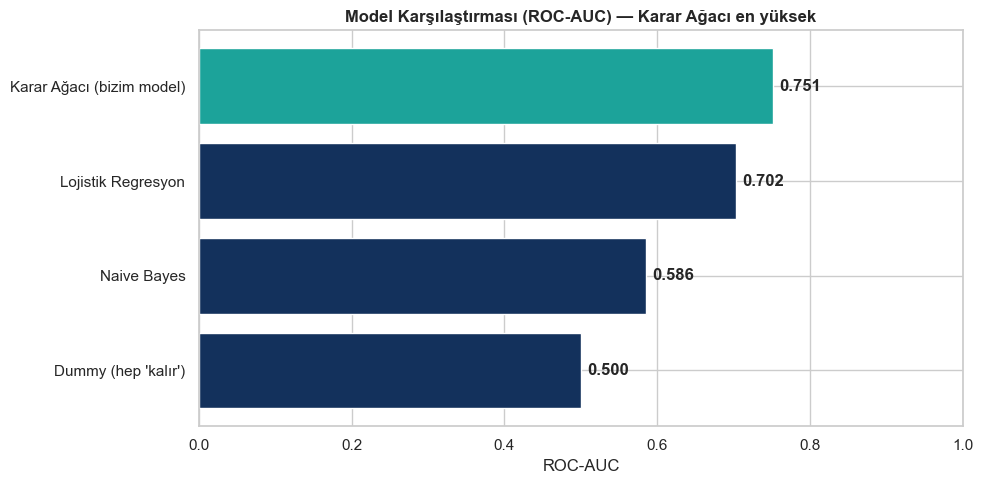

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score

def _baseline_pipe(clf, scale=False):
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("sc", StandardScaler()))
    prep_b = ColumnTransformer(transformers=[
        ("num", Pipeline(num_steps), numeric_cols),
        ("ord", Pipeline([
            ("enc", OrdinalEncoder(categories=ord_categories,
                                   handle_unknown="use_encoded_value", unknown_value=np.nan)),
            ("imp", SimpleImputer(strategy="median"))]), ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
    ])
    return Pipeline([("prep", prep_b), ("clf", clf)])

adaylar = {
    "Dummy (hep 'kalır')": _baseline_pipe(DummyClassifier(strategy="most_frequent")),
    "Lojistik Regresyon":  _baseline_pipe(LogisticRegression(max_iter=2000, class_weight="balanced"), scale=True),
    "Naive Bayes":         _baseline_pipe(GaussianNB()),
}

rows = []
for ad, mdl in adaylar.items():
    mdl.fit(X_train, y_train)
    pp = mdl.predict(X_test); pb = mdl.predict_proba(X_test)[:, 1]
    rows.append([ad, accuracy_score(y_test, pp), balanced_accuracy_score(y_test, pp),
                 recall_score(y_test, pp), f1_score(y_test, pp), roc_auc_score(y_test, pb)])
# Bizim model (Karar Ağacı)
rows.append(["Karar Ağacı (bizim model)", accuracy, balanced_accuracy_score(y_test, y_pred),
             recall, f1, roc_auc])

karsilastirma = pd.DataFrame(rows, columns=["Model", "Accuracy", "Balanced Acc", "Recall", "F1", "ROC-AUC"])
print("=== BASELINE MODEL KARŞILAŞTIRMASI ===")
print(karsilastirma.round(3).to_string(index=False))

# Görselleştirme: ROC-AUC'ye göre
order = karsilastirma.sort_values("ROC-AUC")
colors = ["#1CA39A" if "bizim" in m else "#13315C" for m in order["Model"]]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(order["Model"], order["ROC-AUC"], color=colors)
for i, v in enumerate(order["ROC-AUC"]):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontweight="bold")
ax.set_xlim(0, 1); ax.set_xlabel("ROC-AUC")
ax.set_title("Model Karşılaştırması (ROC-AUC) — Karar Ağacı en yüksek", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR + "model_baseline_karsilastirma.png", dpi=200, bbox_inches="tight")
plt.show()
